# Metal Coil Defect Analysis
**Production Line Sensor Data — Defect Prediction Pipeline**

This notebook covers:
1. Data loading and gappy-coil removal
2. Coil-level aggregation (single pass, reused throughout)
3. EDA — defect prevalence, coil lengths, affected row distributions
4. Semantic feature grouping and cross-group correlation
5. Union-Find group merging
6. Dimensionality reduction (PCA per group, K-Best for Miscellaneous)
7. **Hyperparameter tuning** — GroupKFold-aware search (run once, shared across all targets)
8. **XGBoost** — trained for each of `DIF_TIPO_1` … `DIF_TIPO_6` + `any_defect`
9. **Evaluation** — Accuracy, ROC-AUC, Gain chart, Lift chart, Confusion Matrix
10. Feature Importances & SHAP (last fold, per target)


## 0 — Imports & Constants

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from google.colab import drive
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)
from sklearn.model_selection import GroupKFold, ParameterGrid
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ── All tunable parameters in one place ──────────────────────────────────────
FILE_PATH      = '/content/drive/MyDrive/Colab Notebooks/BBS/Machine Learning Fieldwork/Data/plc_defect_merged.csv'
DEFECT_COLS    = [f'DIF_TIPO_{i}' for i in range(1, 7)]
EXCLUDED_COLS  = {'COIL', 'DATE', 'TIME_START_PROCESS', 'MT'} | set(DEFECT_COLS) | {'ANY_DEFECT'}
CORR_THRESHOLD = 0.85   # groups with |r| >= this are merged
PCA_VARIANCE   = 0.95   # fraction of variance retained per group
KBEST_K        = 29     # target number of features for Miscellaneous group
N_SPLITS       = 5      # GroupKFold folds

# All targets: individual defect types + disjunction
TARGETS             = [f'DIF_TIPO_{i}' for i in range(1, 7)] + ['ANY_DEFECT']

# Proxy target for hyperparameter search.
# The defect types share similar statistical properties (binary, low prevalence,
# same feature space), so tuning once on this proxy is sufficient.
TUNING_PROXY_TARGET = 'DIF_TIPO_3'

SEMANTIC_PREFIXES = {
    'TEMP_Z':     'Temperature_Zones',
    'PYRO_':      'Pyrometers',
    'LASER_FRN':  'Laser_Furnace',
    'AIR_CH':     'Air_Channels',
    'AIR_Z':      'Air_Zones',
    'GAS_Z':      'Gas_Zones',
    'PRES_ZONA':  'Pressure_Zones',
    'VENT_':      'Ventilation',
    'COOL':       'Cooling',
    'LASER_RAFF': 'Laser_Cooling',
}

print('Constants defined.')


Constants defined.


## 1 — Load Data & Mount Drive

In [ ]:
df = pd.read_csv(FILE_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df['ANY_DEFECT']=df['HAS_DEFECT']
df.drop(columns=['HAS_DEFECT'], inplace=True)
display(df.head(3))

Loaded: 298,851 rows × 120 columns


,COIL,DATE,MT,TIME_START_PROCESS,SPEED_PROCESS,TEMP_Z1,TEMP_Z2,TEMP_Z3,TEMP_Z4,TEMP_Z5,...,IS_TAIL_FINISHING,IS_TAIL_RAFFINATION,IS_TAIL_PICKLING,DIF_TIPO_1,DIF_TIPO_2,DIF_TIPO_3,DIF_TIPO_4,DIF_TIPO_5,DIF_TIPO_6,ANY_DEFECT
0,240627,2019-03-15,0.0,14:25:23.060,16.934625,671.967562,679.751438,688.119187,716.71725,734.616563,...,1,0,1,0,0,0,0,0,0,0
1,240627,2019-03-15,7.0,14:25:53.060,16.773638,668.635875,676.207125,681.034500,710.09325,729.040500,...,1,0,1,0,0,0,0,0,0,0
2,240627,2019-03-15,14.0,14:26:23.060,11.142165,669.105375,677.042625,678.493125,707.96775,727.783500,...,1,0,1,0,0,0,0,0,0,0


## 2 — Remove Gappy Coils
Coils where any consecutive MT gap exceeds 7 m are dropped.

In [ ]:
df.sort_values(['COIL', 'MT'], inplace=True)

mt_diff    = df.groupby('COIL', sort=False)['MT'].diff().fillna(0)
gappy_ids  = df.loc[mt_diff > 7, 'COIL'].unique()
gappy_mask = df['COIL'].isin(gappy_ids)

# Check if the gappy coils present more defects than the non-gappy ones

defect_comparison = {}

# --- Non-gappy coils ---
non_gappy_df = df[~gappy_mask].copy()
non_gappy_coil_agg = non_gappy_df.groupby('COIL', sort=False)[DEFECT_COLS].max()

# --- Gappy coils ---
gappy_df = df[gappy_mask].copy()
gappy_coil_agg = gappy_df.groupby('COIL', sort=False)[DEFECT_COLS].max()

for defect_col in DEFECT_COLS:
    non_gappy_defect_pct = non_gappy_coil_agg[defect_col].mean() if not non_gappy_coil_agg.empty else 0
    gappy_defect_pct     = gappy_coil_agg[defect_col].mean() if not gappy_coil_agg.empty else 0
    defect_comparison[defect_col] = {
        'Non-Gappy Coils': non_gappy_defect_pct,
        'Gappy Coils': gappy_defect_pct
    }

defect_comparison_df = pd.DataFrame(defect_comparison).T
print('Defect prevalence comparison (Gappy vs. Non-Gappy Coils):')
display(defect_comparison_df)

length_stats = (
    df[gappy_mask]
    .groupby('COIL', sort=False)['MT'].max()
    .agg(['mean', 'min', 'max'])
)
total_coils = df['COIL'].nunique()

print(f'\nTotal coils            : {total_coils}')
print(f'Gappy coils            : {len(gappy_ids)}  '
      f'({len(gappy_ids)/total_coils:.4f})')
print(f'Gappy coil length      : '
      f'avg={length_stats["mean"]:.2f}  '
      f'min={length_stats["min"]:.2f}  '
      f'max={length_stats["max"]:.2f}')
print(f'Shape before drop      : {df.shape}')

df = df[~gappy_mask].copy()
print(f'Shape after drop       : {df.shape}')

Defect prevalence comparison (Gappy vs. Non-Gappy Coils):


,Non-Gappy Coils,Gappy Coils
DIF_TIPO_1,0.054954,0.000000
DIF_TIPO_2,0.058285,0.025641
DIF_TIPO_3,0.353039,0.128205
DIF_TIPO_4,0.202331,0.102564
DIF_TIPO_5,0.034138,0.000000
DIF_TIPO_6,0.036636,0.025641



Total coils            : 1240
Gappy coils            : 39  (0.0315)
Gappy coil length      : avg=2720.85  min=588.00  max=7252.00
Shape before drop      : (298851, 120)
Shape after drop       : (283242, 120)


## 3 — Coil-Level Aggregation  *(single pass — reused in all EDA sections)*

In [ ]:
coil_agg = df.groupby('COIL', sort=False).agg(
    MT_max=('MT', 'max'),
    **{col: (col, 'max') for col in DEFECT_COLS}
)
coil_agg['ANY_DEFECT'] = coil_agg[DEFECT_COLS].max(axis=1)

print(f'coil_agg shape: {coil_agg.shape}  '
      f'(one row per coil)')
display(coil_agg.head(3))


coil_agg shape: (1201, 8)  (one row per coil)


,MT_max,DIF_TIPO_1,DIF_TIPO_2,DIF_TIPO_3,DIF_TIPO_4,DIF_TIPO_5,DIF_TIPO_6,ANY_DEFECT
COIL,,,,,,,,
352947,2471.0,0,0,0,0,0,0,0
355723,3885.0,0,0,0,0,0,0,0
360028,1708.0,0,0,0,0,0,0,0


## 4 — EDA: Defect Prevalence

Percentage of coils affected by each defect type:


,Defect_Type,Percentage_of_Coils
0,DIF_TIPO_1,0.054954
1,DIF_TIPO_2,0.058285
2,DIF_TIPO_3,0.353039
3,DIF_TIPO_4,0.202331
4,DIF_TIPO_5,0.034138
5,DIF_TIPO_6,0.036636
6,ANY_DEFECT,0.433805


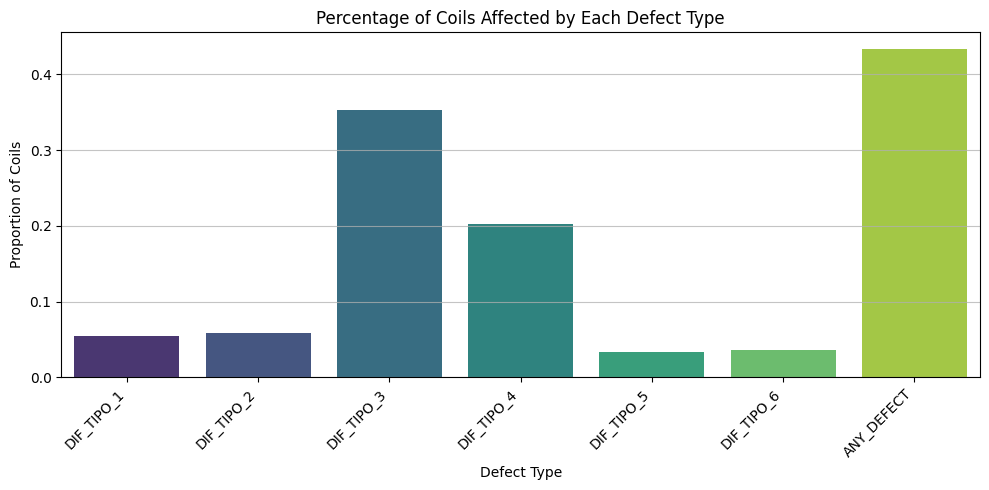

In [ ]:
defect_pct_df = (
    coil_agg[DEFECT_COLS + ['ANY_DEFECT']]
    .mean()
    .rename_axis('Defect_Type')
    .reset_index(name='Percentage_of_Coils')
)

print('Percentage of coils affected by each defect type:')
display(defect_pct_df)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    x='Defect_Type', y='Percentage_of_Coils',
    data=defect_pct_df, palette='viridis',
    hue='Defect_Type', legend=False, ax=ax
)
ax.set(
    title='Percentage of Coils Affected by Each Defect Type',
    xlabel='Defect Type',
    ylabel='Proportion of Coils'
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

## 5 — EDA: Coil Length by Defect Type

Coil length metrics by defect type:


,Defect_Type,Average_Coil_Length,Min_Coil_Length,Max_Coil_Length
0,DIF_TIPO_1,1040.560606,469.0,2149.0
1,DIF_TIPO_2,1507.300000,539.0,4102.0
2,DIF_TIPO_3,1428.676887,287.0,4774.0
3,DIF_TIPO_4,1567.740741,112.0,4375.0
4,DIF_TIPO_5,1563.731707,574.0,2933.0
5,DIF_TIPO_6,1218.636364,581.0,2394.0
6,NO_DEFECT,1688.091176,350.0,7273.0


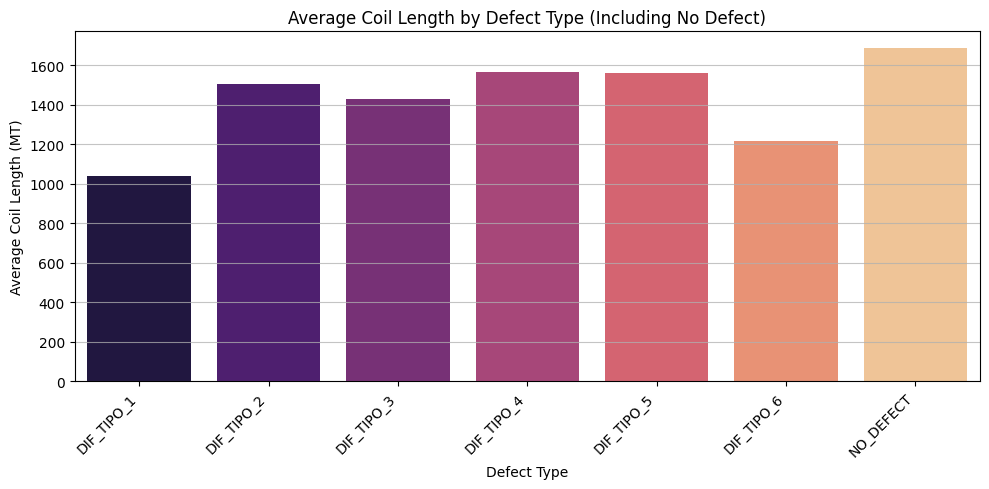

In [ ]:
length_records = []
for col, mask in ([(c, coil_agg[c] == 1) for c in DEFECT_COLS] +
                  [('NO_DEFECT', coil_agg['ANY_DEFECT'] == 0)]):
    lengths = coil_agg.loc[mask, 'MT_max']
    if lengths.empty:
        length_records.append({
            'Defect_Type': col,
            'Average_Coil_Length': 0,
            'Min_Coil_Length': 0,
            'Max_Coil_Length': 0
        })
    else:
        length_records.append({
            'Defect_Type': col,
            'Average_Coil_Length': lengths.mean(),
            'Min_Coil_Length':     lengths.min(),
            'Max_Coil_Length':     lengths.max()
        })

coil_lengths_df = pd.DataFrame(length_records)
print('Coil length metrics by defect type:')
display(coil_lengths_df)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    x='Defect_Type', y='Average_Coil_Length',
    data=coil_lengths_df, palette='magma',
    hue='Defect_Type', legend=False, ax=ax
)
ax.set(
    title='Average Coil Length by Defect Type (Including No Defect)',
    xlabel='Defect Type',
    ylabel='Average Coil Length (MT)'
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

## 6 — EDA: Average % of Rows Affected per Coil

Average % of rows affected (only coils with defect):


,Defect_Type,Average_Affected_Row_Percentage
0,DIF_TIPO_1,0.703172
1,DIF_TIPO_2,0.636660
2,DIF_TIPO_3,0.963382
3,DIF_TIPO_4,0.924789
4,DIF_TIPO_5,0.787778
5,DIF_TIPO_6,0.909257


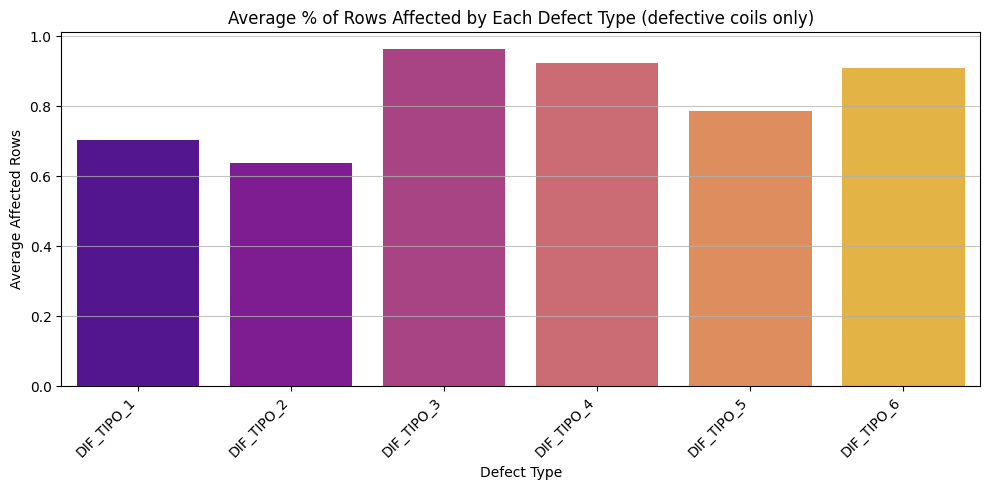

In [ ]:
avg_row_pct = []
for col in DEFECT_COLS:
    # transform is vectorized — avoids apply+lambda per group
    per_coil = (
        df.assign(_m=df.groupby('COIL', sort=False)[col].transform('mean'))
          .groupby('COIL', sort=False)['_m'].first()
    )
    defective = per_coil[per_coil > 0]
    avg_row_pct.append({
        'Defect_Type': col,
        'Average_Affected_Row_Percentage': defective.mean()
    })

avg_row_pct_df = pd.DataFrame(avg_row_pct)
print('Average % of rows affected (only coils with defect):')
display(avg_row_pct_df)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    x='Defect_Type', y='Average_Affected_Row_Percentage',
    data=avg_row_pct_df, palette='plasma',
    hue='Defect_Type', legend=False, ax=ax
)
ax.set(
    title='Average % of Rows Affected by Each Defect Type (defective coils only)',
    xlabel='Defect Type',
    ylabel='Average Affected Rows'
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

## 7 — EDA: Distribution of Affected-Row % per Coil (Histograms)

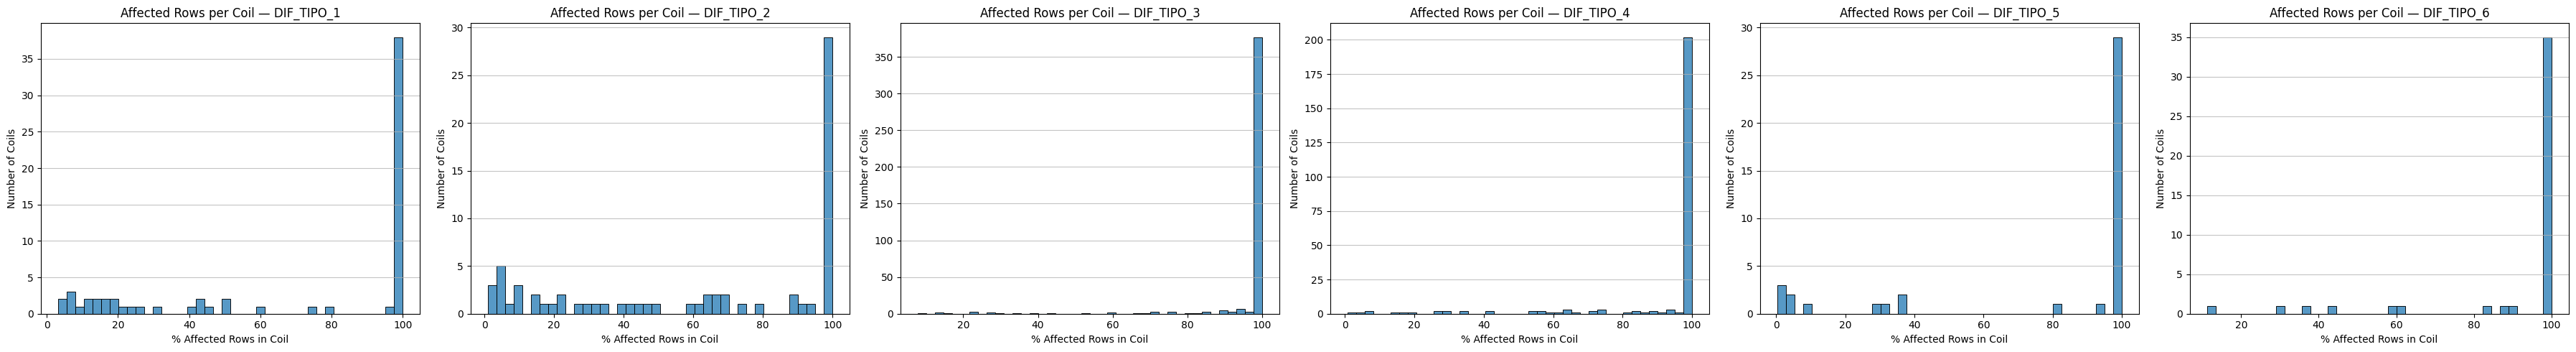

In [ ]:
fig, axes = plt.subplots(
    1, len(DEFECT_COLS),
    figsize=(6 * len(DEFECT_COLS), 5)
)

for ax, col in zip(axes, DEFECT_COLS):
    per_coil_pct = (
        df.groupby('COIL', sort=False)[col]
          .mean()
          .mul(100)
          .pipe(lambda s: s[s > 0])
    )
    sns.histplot(per_coil_pct, bins=40, kde=False, ax=ax)
    ax.set(
        title=f'Affected Rows per Coil — {col}',
        xlabel='% Affected Rows in Coil',
        ylabel='Number of Coils'
    )
    ax.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

## 8 — Feature Grouping by Semantic Prefix

In [ ]:
# Working copy for the classification pipeline — never mutate df
df_clf = df.copy()

feature_cols = [
    c for c in df_clf.select_dtypes(include=np.number).columns
    if c not in EXCLUDED_COLS
]
print(f'Features available for grouping: {len(feature_cols)}')

semantic_groups: dict = {v: [] for v in SEMANTIC_PREFIXES.values()}
semantic_groups['Miscellaneous'] = []

for col in feature_cols:
    for prefix, group in SEMANTIC_PREFIXES.items():
        if col.startswith(prefix):
            semantic_groups[group].append(col)
            break
    else:
        semantic_groups['Miscellaneous'].append(col)

# Drop empty groups
semantic_groups = {k: v for k, v in semantic_groups.items() if v}

print('\nInitial semantic groups:')
for g, cols in semantic_groups.items():
    print(f'  {g}: {len(cols)} features')


Features available for grouping: 109

Initial semantic groups:
  Temperature_Zones: 6 features
  Pyrometers: 3 features
  Laser_Furnace: 9 features
  Air_Channels: 6 features
  Air_Zones: 12 features
  Gas_Zones: 12 features
  Pressure_Zones: 6 features
  Ventilation: 5 features
  Cooling: 5 features
  Laser_Cooling: 9 features
  Miscellaneous: 36 features


## 9 — Initial Cross-Group Correlation

Initial correlation matrix of semantic group representatives:


,Temperature_Zones,Pyrometers,Laser_Furnace,Air_Channels,Air_Zones,Gas_Zones,Pressure_Zones,Ventilation,Cooling,Laser_Cooling,Miscellaneous
Temperature_Zones,1.000000,0.812527,0.600924,-0.163615,0.503641,0.522413,0.018889,0.361041,0.597822,0.435742,0.205464
Pyrometers,0.812527,1.000000,0.600707,-0.161472,0.265209,0.276952,-0.000569,0.192864,0.336078,0.242797,0.090532
Laser_Furnace,0.600924,0.600707,1.000000,-0.087921,0.607996,0.637129,-0.031080,0.300019,0.430852,0.544782,0.517160
Air_Channels,-0.163615,-0.161472,-0.087921,1.000000,0.087302,0.048464,-0.002305,0.021543,-0.003188,0.032833,0.037076
Air_Zones,0.503641,0.265209,0.607996,0.087302,1.000000,0.982199,0.030103,0.592091,0.649234,0.698433,0.644798
Gas_Zones,0.522413,0.276952,0.637129,0.048464,0.982199,1.000000,0.033279,0.623773,0.653204,0.707084,0.675176
Pressure_Zones,0.018889,-0.000569,-0.031080,-0.002305,0.030103,0.033279,1.000000,0.260889,-0.092417,-0.071638,0.005278
Ventilation,0.361041,0.192864,0.300019,0.021543,0.592091,0.623773,0.260889,1.000000,0.104812,0.040231,0.327469
Cooling,0.597822,0.336078,0.430852,-0.003188,0.649234,0.653204,-0.092417,0.104812,1.000000,0.875315,0.438575
Laser_Cooling,0.435742,0.242797,0.544782,0.032833,0.698433,0.707084,-0.071638,0.040231,0.875315,1.000000,0.642283


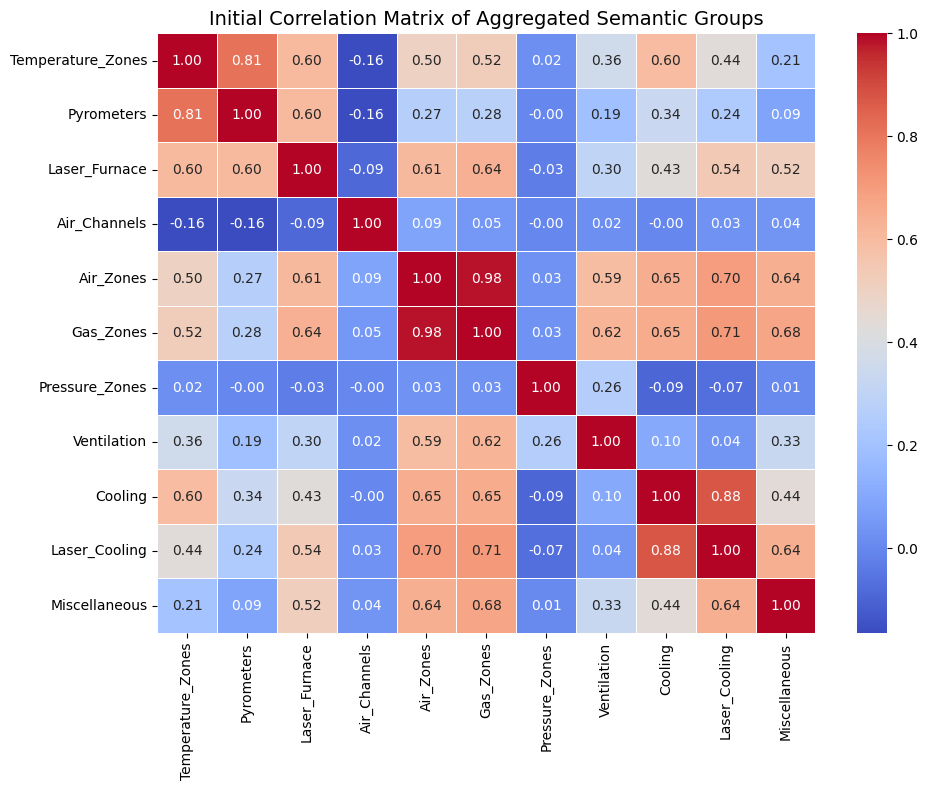

In [ ]:
# Representative of each group = mean of its sensors (row-wise)
group_reps = pd.DataFrame({
    g: df_clf[cols].mean(axis=1)
    for g, cols in semantic_groups.items()
})
init_corr = group_reps.corr()

print('Initial correlation matrix of semantic group representatives:')
display(init_corr)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    init_corr, annot=True, cmap='coolwarm',
    fmt='.2f', linewidths=.5, ax=ax
)
ax.set_title(
    'Initial Correlation Matrix of Aggregated Semantic Groups',
    fontsize=14
)
plt.tight_layout()
plt.show()

## 10 — Merge Correlated Groups  *(Union-Find)*

Final merged groups (threshold = 0.85):
  Temperature_Zones: 6 features
  Pyrometers: 3 features
  Laser_Furnace: 9 features
  Air_Channels: 6 features
  Air_Zones: 24 features
  Pressure_Zones: 6 features
  Ventilation: 5 features
  Cooling: 14 features
  Miscellaneous: 36 features


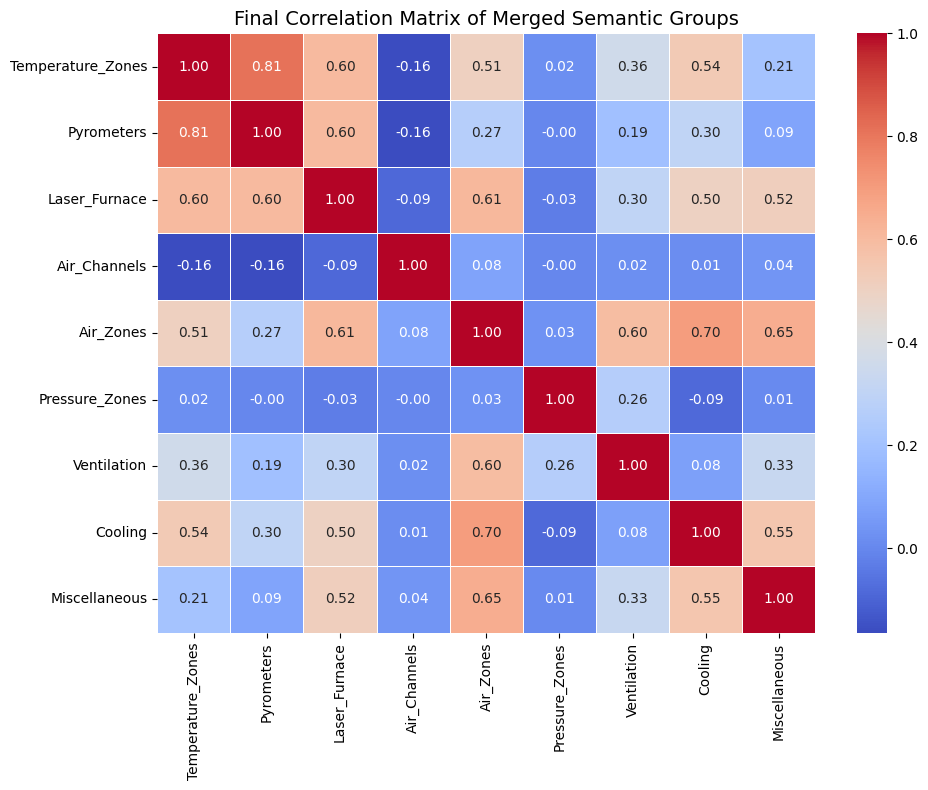

In [ ]:
parent  = {g: g for g in semantic_groups}
members = {g: list(cols) for g, cols in semantic_groups.items()}

def find(i):
    """Iterative find with two-step path compression."""
    while parent[i] != i:
        parent[i] = parent[parent[i]]
        i = parent[i]
    return i

def union(i, j):
    ri, rj = find(i), find(j)
    if ri != rj:
        members[ri].extend(members.pop(rj))
        parent[rj] = ri

groups_list = list(semantic_groups)
for i in range(len(groups_list)):
    for j in range(i + 1, len(groups_list)):
        if abs(init_corr.loc[groups_list[i], groups_list[j]]) >= CORR_THRESHOLD:
            union(groups_list[i], groups_list[j])

final_groups = members
print(f'Final merged groups (threshold = {CORR_THRESHOLD}):')
for g, cols in final_groups.items():
    print(f'  {g}: {len(cols)} features')

# Final correlation heatmap after merging
final_reps = pd.DataFrame({
    g: df_clf[cols].mean(axis=1)
    for g, cols in final_groups.items()
})
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    final_reps.corr(), annot=True, cmap='coolwarm',
    fmt='.2f', linewidths=.5, ax=ax
)
ax.set_title(
    'Final Correlation Matrix of Merged Semantic Groups',
    fontsize=14
)
plt.tight_layout()
plt.show()

## 11 — Dimensionality Reduction
- **PCA** (95% variance) for all named semantic groups  
- **K-Best** (SelectKBest with f_regression) for the Miscellaneous group. Since this group is composed of features which are not semantically related with one-another, it could be difficult to interpret the resulting principal components in terms of the initial Miscellaneous features. Thus, a more cautious approach is chosen, selecting only a fixed number of features (29).

> ⚠️ **Note:** In the anomaly-detection pipeline, scalers and PCA must be fit **on clean coils only** and then applied to all coils.  
> Here, for the classification pipeline, we fit on the full `df_clf`.

In [ ]:
transformed_parts = []   # collect chunks, concat once at the end

print('Applying dimensionality reduction per semantic group:\n')

for group_name, cols in final_groups.items():
    group_data = df_clf[cols].copy()

    # ── Guard: drop constant columns ─────────────────────────────────────
    constant = group_data.columns[group_data.nunique() == 1]
    if not constant.empty:
        print(f'  [{group_name}] dropping cps2pdf -dPDFSETTINGS=/ebook input.pdf output.pdfonstant cols: {list(constant)}')
        group_data.drop(columns=constant, inplace=True)
    if group_data.empty:
        print(f'  [{group_name}] empty after constant drop — skipping')
        continue

    # ── Guard: impute NaNs ───────────────────────────────────────────────
    if group_data.isna().any(axis=None):
        print(f'  [{group_name}] NaN values found — imputing with column mean')
        group_data.fillna(group_data.mean(), inplace=True)

    scaler      = StandardScaler()
    scaled_data = scaler.fit_transform(group_data)

    # ════════════════════════════════════════════════════════════════════
    if group_name == 'Miscellaneous':
    # ── K-Best path ─────────────────────────────────────────────────────
        y_mt = df_clf.loc[group_data.index, 'MT']
        part_arrays, part_names = [], []
        scaled_data_for_kbest = scaled_data.copy() # Make a copy for k-best
        group_data_for_kbest  = group_data.copy() # Make a copy for feature names

        if 'MT' in group_data_for_kbest.columns:
            mt_idx = list(group_data_for_kbest.columns).index('MT')
            # Extract MT feature and its scaled version
            mt_scaled_col = scaled_data_for_kbest[:, [mt_idx]]
            part_arrays.append(mt_scaled_col)
            part_names.append(f'{group_name}_MT_Scaled')

            # Remove MT from data to be used by SelectKBest
            non_mt_cols = np.ones(scaled_data_for_kbest.shape[1], dtype=bool)
            non_mt_cols[mt_idx] = False
            scaled_data_for_kbest = scaled_data_for_kbest[:, non_mt_cols]
            group_data_for_kbest  = group_data_for_kbest.drop(columns=['MT'])

        k = min(KBEST_K - len(part_arrays), scaled_data_for_kbest.shape[1])

        variance_retained_pct = 0 # Initialize

        if k > 0 and scaled_data_for_kbest.shape[1] > 0:
            # Calculate total variance of features considered for k-best *before* selection
            original_kbest_variance = np.var(scaled_data_for_kbest, axis=0).sum()

            selector = SelectKBest(f_regression, k=k)
            selected_features_data = selector.fit_transform(scaled_data_for_kbest, y_mt)
            sel_names = group_data_for_kbest.columns[selector.get_support(indices=True)]
            part_arrays.append(selected_features_data)
            part_names.extend([f'{group_name}_{n}' for n in sel_names])

            # Calculate total variance of selected features
            selected_kbest_variance = np.var(selected_features_data, axis=0).sum()

            if original_kbest_variance > 0:
                variance_retained_pct = (selected_kbest_variance / original_kbest_variance) * 100
            else:
                variance_retained_pct = 0 # No variance to begin with

        if part_arrays:
            chunk = pd.DataFrame(
                np.concatenate(part_arrays, axis=1),
                columns=part_names,
                index=df_clf.index
            )
            transformed_parts.append(chunk)
            print(f'  [{group_name}] original={len(cols)}  '
                  f'k-best={chunk.shape[1]}')
            if k > 0 and scaled_data_for_kbest.shape[1] > 0: # Only print if k-best was actually applied to some features
                print(f'  [{group_name}] variance retained after K-Best: {variance_retained_pct:.2f}%')
        else:
            print(f'  [{group_name}] no components generated')

    # ════════════════════════════════════════════════════════════════════
    else:
    # ── PCA path ────────────────────────────────────────────────────────
        pca        = PCA(n_components=PCA_VARIANCE)
        components = pca.fit_transform(scaled_data)
        col_names  = [f'{group_name}_PC{i+1}'
                      for i in range(components.shape[1])]
        transformed_parts.append(
            pd.DataFrame(components, columns=col_names, index=df_clf.index)
        )
        print(f'  [{group_name}] original={len(cols)}  '
              f'PCA components={components.shape[1]}  '
              f'explained={pca.explained_variance_ratio_.sum():.4f}')

# Single concat — avoids O(n²) cost of repeated concat inside the loop
df_transformed = pd.concat(transformed_parts, axis=1)

print(f'\nOriginal shape    : {df_clf.shape}')
print(f'Transformed shape : {df_transformed.shape}')
display(df_transformed.head(3))

Applying dimensionality reduction per semantic group:

  [Temperature_Zones] original=6  PCA components=2  explained=0.9877
  [Pyrometers] original=3  PCA components=3  explained=1.0000
  [Laser_Furnace] original=9  PCA components=5  explained=0.9953
  [Air_Channels] original=6  PCA components=6  explained=1.0000
  [Air_Zones] original=24  PCA components=4  explained=0.9729
  [Pressure_Zones] dropping constant cols: ['PRES_ZONA1_SET', 'PRES_ZONA2_SET', 'PRES_ZONA3_SET']
  [Pressure_Zones] NaN values found — imputing with column mean
  [Pressure_Zones] original=6  PCA components=3  explained=1.0000
  [Ventilation] NaN values found — imputing with column mean
  [Ventilation] original=5  PCA components=3  explained=0.9663
  [Cooling] NaN values found — imputing with column mean
  [Cooling] original=14  PCA components=4  explained=0.9571
  [Miscellaneous] NaN values found — imputing with column mean
  [Miscellaneous] original=36  k-best=29
  [Miscellaneous] variance retained after K-Best: 

,Temperature_Zones_PC1,Temperature_Zones_PC2,Pyrometers_PC1,Pyrometers_PC2,Pyrometers_PC3,Laser_Furnace_PC1,Laser_Furnace_PC2,Laser_Furnace_PC3,Laser_Furnace_PC4,Laser_Furnace_PC5,...,Miscellaneous_TIRO_DECAP,Miscellaneous_SPEED_FILL,Miscellaneous_FILL_FORZA,Miscellaneous_FILL_TIRO,Miscellaneous_FILL_ALL,Miscellaneous_FILL_BENDING_POS,Miscellaneous_FILL_BENDING_NEG,Miscellaneous_IS_TAIL_FINISHING,Miscellaneous_IS_TAIL_RAFFINATION,Miscellaneous_IS_TAIL_PICKLING
1517,0.233609,0.083908,0.811185,0.472239,0.452891,1.638903,2.168420,0.021189,-0.677172,0.336596,...,-7.133262e-16,-0.396728,-1.242647,-0.005972,-0.046610,-0.268450,-0.961098,-0.307324,-0.225949,4.482915
1518,0.189673,0.077471,0.773187,0.432822,0.549330,1.387524,2.181950,0.022626,-0.668107,0.323453,...,-7.133262e-16,1.357479,-1.398689,-0.077601,0.635482,-0.037493,-0.958996,-0.307324,-0.225949,4.482915
1519,0.152630,0.072022,0.844777,0.740995,0.386802,1.244186,2.194348,0.026030,-0.661786,0.314546,...,-7.133262e-16,1.383004,-1.402799,-0.073765,0.449243,-0.037703,-0.960263,-0.307324,-0.225949,4.482915


## 12 — Dimensionality Reduction Summary

In [ ]:
misc_cols  = [c for c in df_transformed.columns if c.startswith('Miscellaneous_')]
orig_misc  = len(final_groups.get('Miscellaneous', []))

print(f'Miscellaneous group: {orig_misc} → {len(misc_cols)} features  '
      f'({(orig_misc - len(misc_cols)) / orig_misc * 100:.1f}% reduction)')
print(f'\nAll transformed columns ({len(df_transformed.columns)} total):')
display(pd.Series(df_transformed.columns.tolist(), name='feature'))

Miscellaneous group: 36 → 29 features  (19.4% reduction)

All transformed columns (59 total):


,feature
0,Temperature_Zones_PC1
1,Temperature_Zones_PC2
2,Pyrometers_PC1
3,Pyrometers_PC2
4,Pyrometers_PC3
5,Laser_Furnace_PC1
6,Laser_Furnace_PC2
7,Laser_Furnace_PC3
8,Laser_Furnace_PC4
9,Laser_Furnace_PC5


## 13 — Shared Feature Matrix Setup


In [ ]:
# Drop MT-scaled feature — coil length could introduce leakage
X_base = df_transformed.drop(
    columns=[c for c in df_transformed.columns if c == 'Miscellaneous_MT_Scaled'],
    errors='ignore'
)
coil_ids = df_clf.loc[X_base.index, 'COIL']

# Defensive index alignment
idx_base = X_base.index.intersection(coil_ids.index)
X_base   = X_base.loc[idx_base]
coil_ids = coil_ids.loc[idx_base]

print(f'Feature matrix : {X_base.shape}')
print(f'Targets        : {TARGETS}')


Feature matrix : (283242, 59)
Targets        : ['DIF_TIPO_1', 'DIF_TIPO_2', 'DIF_TIPO_3', 'DIF_TIPO_4', 'DIF_TIPO_5', 'DIF_TIPO_6', 'ANY_DEFECT']


## 14 — Hyperparameter Tuning  *(GroupKFold, single proxy target)*

> All seven target variables are binary flags on the same feature space and
> share similar class-imbalance levels. Running a full grid search for every
> target would multiply compute by 7× with negligible benefit. Instead we
> tune once on **`TUNING_PROXY_TARGET`** (`DIF_TIPO_3`) and reuse the best
> hyperparameters for all targets.
>
> We use a **manual GroupKFold loop** rather than `GridSearchCV` because
> scikit-learn's `GridSearchCV` does not natively respect group-based splits —
> passing `groups` requires `GroupKFold` directly, which we already have.

**Pre-tuned hyperparameters are already saved below** (`RERUN_TUNING = False`).
Set `RERUN_TUNING = True` in the next cell only if you want to repeat the grid
search (adds ~10–25 min of runtime).


In [ ]:
# ── Toggle: set to True to repeat the grid search ────────────────────────────
RERUN_TUNING = False

# ── Pre-tuned hyperparameters (obtained on this dataset, ROC-AUC ≈ best found)
CACHED_PARAMS = {
    'colsample_bytree': 0.8,
    'learning_rate'   : 0.1,
    'max_depth'       : 5,
    'n_estimators'    : 150,
    'reg_alpha'       : 0.0,
    'reg_lambda'      : 0.5,
    'subsample'       : 0.8,
}

if not RERUN_TUNING:
    best_params_ = CACHED_PARAMS.copy()
    print('Using cached hyperparameters (RERUN_TUNING=False):')
    for k, v in best_params_.items():
        print(f'  {k:20s}: {v}')


Using cached hyperparameters (RERUN_TUNING=False):
  colsample_bytree    : 0.8
  learning_rate       : 0.1
  max_depth           : 5
  n_estimators        : 150
  reg_alpha           : 0.0
  reg_lambda          : 0.5
  subsample           : 0.8


In [ ]:
# ── Grid search — only executed when RERUN_TUNING = True ─────────────────────
if RERUN_TUNING:
    PARAM_GRID = {
        'max_depth'       : [3, 5],
        'learning_rate'   : [0.03, 0.05, 0.10],
        'n_estimators'    : [100, 150, 200],
        'subsample'       : [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
        'reg_alpha'       : [0.0, 0.1],
        'reg_lambda'      : [0.5, 1.0],
    }

    y_proxy  = df_clf.loc[X_base.index, TUNING_PROXY_TARGET]
    gkf      = GroupKFold(n_splits=N_SPLITS)
    splits   = list(gkf.split(X_base, y_proxy, groups=coil_ids))

    best_params_ = None
    best_auc_    = -np.inf
    n_combos     = len(list(ParameterGrid(PARAM_GRID)))
    print(f'Grid size: {n_combos} combinations × {N_SPLITS} folds = {n_combos * N_SPLITS} fits\n')

    for i, params in enumerate(ParameterGrid(PARAM_GRID), 1):
        fold_aucs = []
        for tr, te in splits:
            X_tr, X_te = X_base.iloc[tr], X_base.iloc[te]
            y_tr, y_te = y_proxy.iloc[tr], y_proxy.iloc[te]

            sc = StandardScaler()
            Xtr_sc = sc.fit_transform(X_tr)
            Xte_sc = sc.transform(X_te)

            m = xgb.XGBClassifier(
                objective='binary:logistic',
                eval_metric='logloss',
                random_state=42,
                n_jobs=-1,
                **params
            )
            m.fit(Xtr_sc, y_tr)

            y_proba = m.predict_proba(Xte_sc)[:, 1]
            if len(np.unique(y_te)) < 2:
                fold_aucs.append(0.5)
            else:
                fold_aucs.append(roc_auc_score(y_te, y_proba))

        mean_auc = np.mean(fold_aucs)
        if mean_auc > best_auc_:
            best_auc_    = mean_auc
            best_params_ = params.copy()

        if i % 20 == 0 or i == n_combos:
            print(f'  [{i:>3}/{n_combos}]  current best AUC={best_auc_:.4f}')

    print(f'\nBest ROC-AUC (proxy={TUNING_PROXY_TARGET}): {best_auc_:.4f}')
    print('Best hyperparameters (update CACHED_PARAMS above if you want to save these):')
    for k, v in best_params_.items():
        print(f'  {k:20s}: {v}')


## 15 — XGBoost for All Targets  *(GroupKFold, tuned hyperparameters)*

> One model is trained per target using the best hyperparameters found above.
> Results (accuracy, ROC-AUC, gain, lift) are collected into a summary table.
> Detailed per-fold diagnostics are printed inline.


In [ ]:
# ── Helper: Gain & Lift at decile k ─────────────────────────────────────────
def gain_lift_table(y_true, y_proba, n_bins=10):
    """Return a DataFrame with cumulative Gain and Lift per decile."""
    df_gl = pd.DataFrame({'y_true': y_true, 'y_proba': y_proba})
    df_gl = df_gl.sort_values('y_proba', ascending=False).reset_index(drop=True)
    df_gl['decile'] = pd.qcut(df_gl.index, n_bins, labels=False) + 1
    total_pos = df_gl['y_true'].sum()
    if total_pos == 0:
        return None
    summary = (
        df_gl.groupby('decile', sort=True)['y_true']
             .agg(n_positives='sum', n_total='count')
             .reset_index()
    )
    summary['cum_positives']   = summary['n_positives'].cumsum()
    summary['cum_total']       = summary['n_total'].cumsum()
    summary['gain_pct']        = summary['cum_positives'] / total_pos * 100
    summary['population_pct']  = summary['cum_total'] / len(df_gl) * 100
    summary['lift']            = summary['gain_pct'] / summary['population_pct']
    return summary


def plot_gain_lift(gl_table, target_name, ax_gain, ax_lift):
    """Plot Gain and Lift curves onto provided axes."""
    x = gl_table['population_pct']
    ax_gain.plot(x, gl_table['gain_pct'], marker='o', label=target_name)
    ax_gain.plot([0, 100], [0, 100], 'k--', lw=1, label='Random' if target_name == TARGETS[0] else '_nolegend_')
    ax_gain.set(title='Cumulative Gain Chart', xlabel='% Population (by score)', ylabel='% Positives Captured')
    ax_gain.grid(alpha=0.4)

    ax_lift.plot(x, gl_table['lift'], marker='o', label=target_name)
    ax_lift.axhline(1.0, color='k', linestyle='--', lw=1)
    ax_lift.set(title='Lift Chart', xlabel='% Population (by score)', ylabel='Lift')
    ax_lift.grid(alpha=0.4)

print('Helper functions defined.')


Helper functions defined.



════════════════════════════════════════════════════════════
  Target: DIF_TIPO_1
════════════════════════════════════════════════════════════
  Class balance:
DIF_TIPO_1
0   0.9759
1   0.0241
  Fold 1  acc=0.9819  auc=0.8507
  Fold 2  acc=0.9717  auc=0.9269
  Fold 3  acc=0.9787  auc=0.8534
  Fold 4  acc=0.9853  auc=0.9891
  Fold 5  acc=0.9793  auc=0.9376
  → Mean accuracy : 0.9794 ± 0.0045
  → Mean ROC-AUC  : 0.9115 ± 0.0529

════════════════════════════════════════════════════════════
  Target: DIF_TIPO_2
════════════════════════════════════════════════════════════
  Class balance:
DIF_TIPO_2
0   0.9627
1   0.0373
  Fold 1  acc=0.9646  auc=0.7520
  Fold 2  acc=0.9578  auc=0.5529
  Fold 3  acc=0.9292  auc=0.7467
  Fold 4  acc=0.9673  auc=0.7871
  Fold 5  acc=0.9716  auc=0.7330
  → Mean accuracy : 0.9581 ± 0.0151
  → Mean ROC-AUC  : 0.7144 ± 0.0827

════════════════════════════════════════════════════════════
  Target: DIF_TIPO_3
═══════════════════════════════════════════════════════

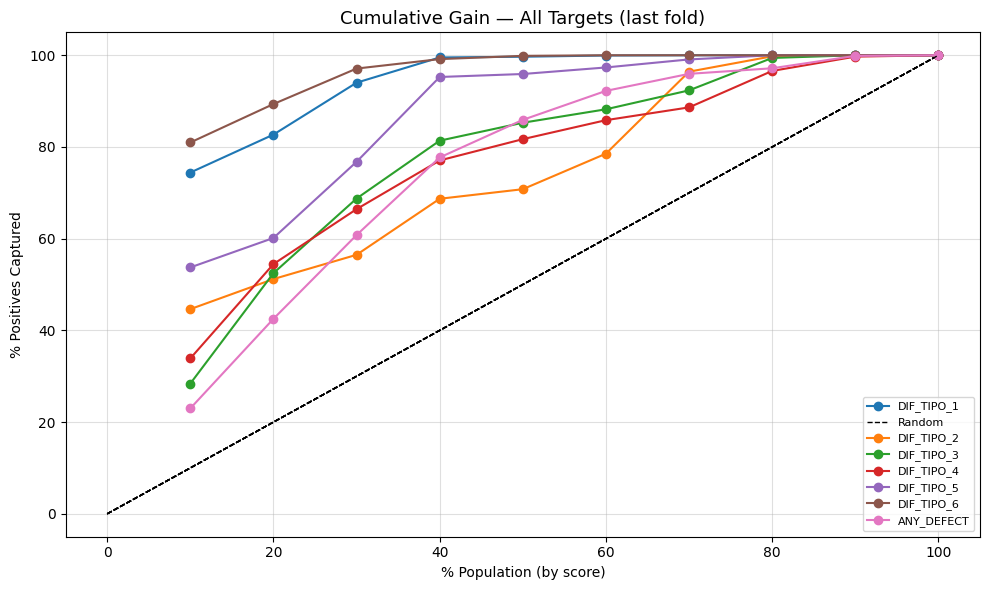

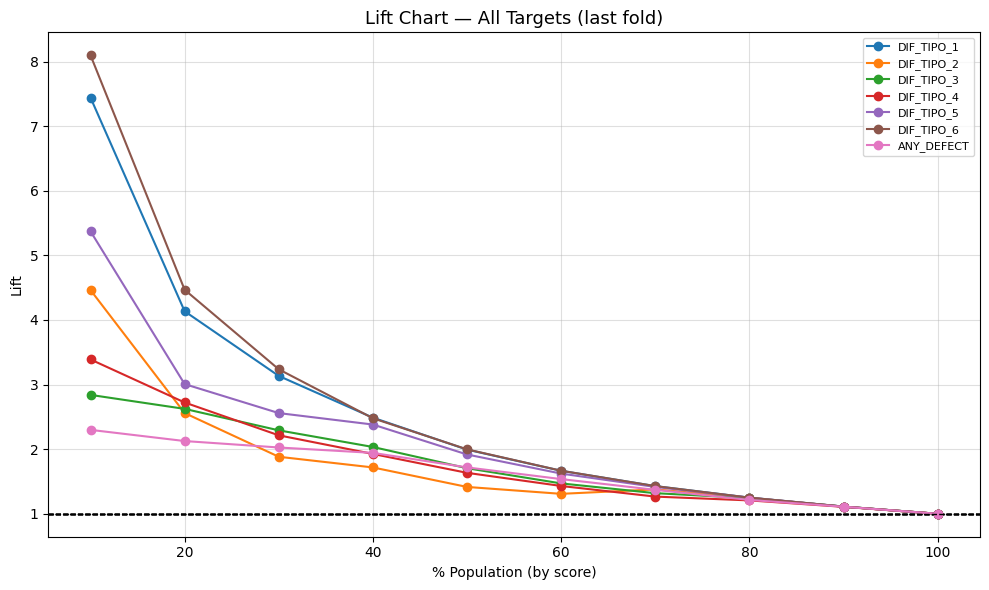

In [ ]:
# ── Main loop: one XGBoost model per target ──────────────────────────────────
all_results          = []   # for summary table
last_fold_artifacts  = {}   # target → (model, X_te, X_te_sc, y_te, y_pred, y_proba, gl_table)

fig_gain, ax_gain = plt.subplots(figsize=(10, 6))
fig_lift, ax_lift = plt.subplots(figsize=(10, 6))

for target in TARGETS:
    print(f'\n{"═"*60}')
    print(f'  Target: {target}')
    print(f'{"═"*60}')

    y        = df_clf.loc[X_base.index, target]
    idx      = X_base.index.intersection(y.index)
    X        = X_base.loc[idx]
    y        = y.loc[idx]
    grp      = coil_ids.loc[idx]

    print(f'  Class balance:')
    print(y.value_counts(normalize=True).rename('proportion').to_string(float_format='{:.4f}'.format))

    gkf             = GroupKFold(n_splits=N_SPLITS)
    accuracy_scores = []
    roc_auc_scores  = []
    # Keep last-fold artifacts for detailed reporting
    model_last = X_te_last = X_te_sc_last = y_te_last = y_pred_last = y_proba_last = None

    for fold, (tr, te) in enumerate(gkf.split(X, y, groups=grp)):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]

        sc      = StandardScaler()
        Xtr_sc  = sc.fit_transform(X_tr)
        Xte_sc  = sc.transform(X_te)

        model = xgb.XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1,ps2pdf -dPDFSETTINGS=/ebook input.pdf output.pdf
            **best_params_
        )
        model.fit(Xtr_sc, y_tr)

        y_pred  = model.predict(Xte_sc)
        y_proba = model.predict_proba(Xte_sc)[:, 1]

        fold_acc = accuracy_score(y_te, y_pred)
        fold_auc = roc_auc_score(y_te, y_proba) if len(np.unique(y_te)) > 1 else float('nan')
        accuracy_scores.append(fold_acc)
        roc_auc_scores.append(fold_auc)

        print(f'  Fold {fold+1}  acc={fold_acc:.4f}  auc={fold_auc:.4f}')

        # Retain last fold
        model_last, X_te_last, X_te_sc_last = model, X_te, Xte_sc
        y_te_last, y_pred_last, y_proba_last = y_te, y_pred, y_proba

    mean_acc = np.nanmean(accuracy_scores)
    std_acc  = np.nanstd(accuracy_scores)
    mean_auc = np.nanmean(roc_auc_scores)
    std_auc  = np.nanstd(roc_auc_scores)
    print(f'  → Mean accuracy : {mean_acc:.4f} ± {std_acc:.4f}')
    print(f'  → Mean ROC-AUC  : {mean_auc:.4f} ± {std_auc:.4f}')

    # Gain/Lift on last fold
    gl_table = gain_lift_table(y_te_last.values, y_proba_last)
    if gl_table is not None:
        plot_gain_lift(gl_table, target, ax_gain, ax_lift)
        lift_top2 = gl_table.loc[gl_table['decile'] == 2, 'lift'].values
        lift_top2 = float(lift_top2[0]) if len(lift_top2) else float('nan')
        gain_top3 = gl_table.loc[gl_table['decile'] == 3, 'gain_pct'].values
        gain_top3 = float(gain_top3[0]) if len(gain_top3) else float('nan')
    else:
        lift_top2, gain_top3 = float('nan'), float('nan')

    all_results.append({
        'Target'          : target,
        'Mean Accuracy'   : round(mean_acc, 4),
        'Std Accuracy'    : round(std_acc,  4),
        'Mean ROC-AUC'    : round(mean_auc, 4),
        'Std ROC-AUC'     : round(std_auc,  4),
        'Lift @top-20%'   : round(lift_top2, 3),
        'Gain @top-30%'   : round(gain_top3, 1),
    })

    last_fold_artifacts[target] = (
        model_last, X_te_last, X_te_sc_last,
        y_te_last, y_pred_last, y_proba_last, gl_table
    )

# Finalise combined gain/lift charts
for ax, fig, title in [
    (ax_gain, fig_gain, 'Cumulative Gain — All Targets (last fold)'),
    (ax_lift, fig_lift, 'Lift Chart — All Targets (last fold)'),
]:
    ax.set_title(title, fontsize=13)
    ax.legend(loc='lower right' if 'Gain' in title else 'upper right', fontsize=8)
    fig.tight_layout()
    fig.show()


## 16 — Cross-Target Results Summary

| Column | Meaning |
|---|---|
| **Mean Accuracy** | Average classification accuracy across 5 GroupKFold folds |
| **Mean ROC-AUC** | Area under the ROC curve — threshold-independent ranking quality |
| **Lift @top-20%** | How many times more defects are found in the top-scoring 20% of coils vs. random |
| **Gain @top-30%** | % of all actual defects captured by scoring the top 30% of coils |


In [ ]:
results_df = pd.DataFrame(all_results).set_index('Target')
print('Cross-target XGBoost performance summary:')
display(results_df.style
    .background_gradient(subset=['Mean ROC-AUC', 'Lift @top-20%', 'Gain @top-30%'], cmap='YlGn')
    .format(precision=4)
)


Cross-target XGBoost performance summary:


,Mean Accuracy,Std Accuracy,Mean ROC-AUC,Std ROC-AUC,Lift @top-20%,Gain @top-30%
Target,,,,,,
DIF_TIPO_1,0.9794,0.0045,0.9115,0.0529,4.1350,94.0000
DIF_TIPO_2,0.9581,0.0151,0.7144,0.0827,2.5600,56.5000
DIF_TIPO_3,0.8309,0.0126,0.8867,0.0106,2.6240,68.8000
DIF_TIPO_4,0.8523,0.0123,0.8318,0.0265,2.7230,66.4000
DIF_TIPO_5,0.9700,0.0072,0.7724,0.1206,3.0080,76.8000
DIF_TIPO_6,0.9829,0.0032,0.9640,0.0233,4.4680,97.1000
ANY_DEFECT,0.8114,0.0096,0.8814,0.0170,2.1260,60.8000


## 17 — Per-Target: Confusion Matrix & Classification Report  *(last fold)*


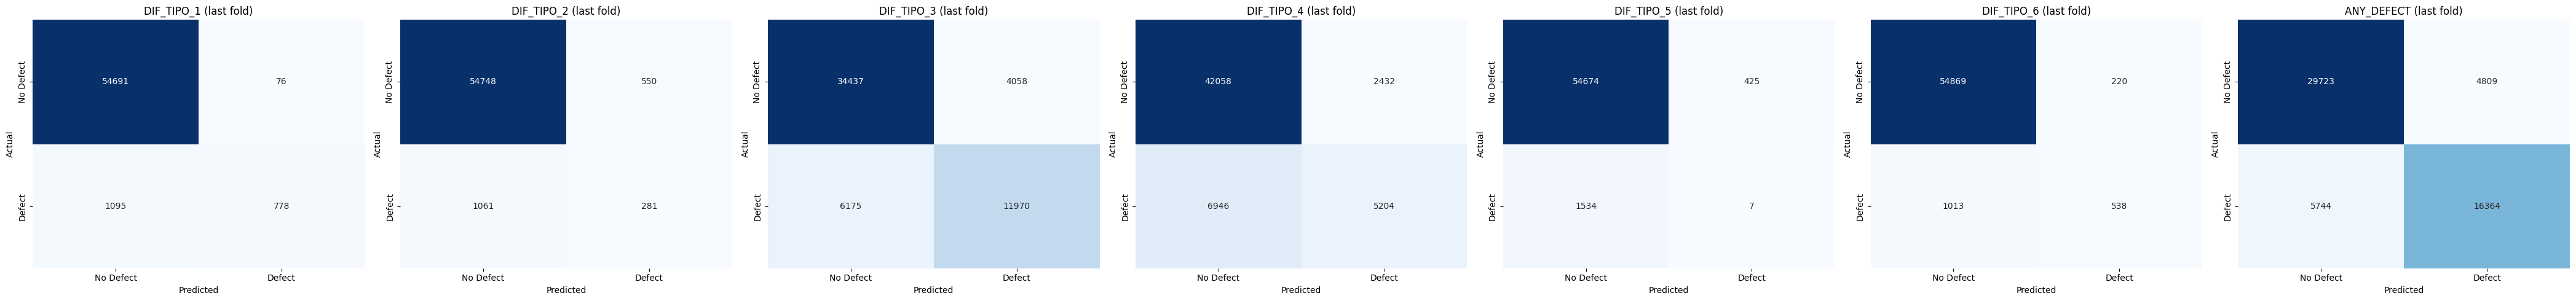


── DIF_TIPO_1 ──
              precision    recall  f1-score   support

   No Defect       0.98      1.00      0.99     54767
      Defect       0.91      0.42      0.57      1873

    accuracy                           0.98     56640
   macro avg       0.95      0.71      0.78     56640
weighted avg       0.98      0.98      0.98     56640


── DIF_TIPO_2 ──
              precision    recall  f1-score   support

   No Defect       0.98      0.99      0.99     55298
      Defect       0.34      0.21      0.26      1342

    accuracy                           0.97     56640
   macro avg       0.66      0.60      0.62     56640
weighted avg       0.97      0.97      0.97     56640


── DIF_TIPO_3 ──
              precision    recall  f1-score   support

   No Defect       0.85      0.89      0.87     38495
      Defect       0.75      0.66      0.70     18145

    accuracy                           0.82     56640
   macro avg       0.80      0.78      0.79     56640
weighted avg       0

In [ ]:
n_targets = len(TARGETS)
fig, axes = plt.subplots(1, n_targets, figsize=(6 * n_targets, 5))
if n_targets == 1:
    axes = [axes]

for ax, target in zip(axes, TARGETS):
    model, X_te, X_te_sc, y_te, y_pred, y_proba, _ = last_fold_artifacts[target]
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', cbar=False,
        xticklabels=['No Defect', 'Defect'],
        yticklabels=['No Defect', 'Defect'],
        ax=ax
    )
    ax.set(title=f'{target} (last fold)', xlabel='Predicted', ylabel='Actual')

plt.tight_layout()
plt.show()

for target in TARGETS:
    _, _, _, y_te, y_pred, _, _ = last_fold_artifacts[target]
    print(f'\n── {target} ──')
    print(classification_report(y_te, y_pred, target_names=['No Defect', 'Defect']))


## 18 — Per-Target: Gain & Lift Tables  *(last fold)*

Each table shows, for coils ranked by descending defect-probability score,
how much of the defect population is captured as we inspect larger fractions
of the fleet. **Lift > 1** means the model outperforms random selection.


In [ ]:
for target in TARGETS:
    _, _, _, _, _, _, gl_table = last_fold_artifacts[target]
    print(f'\n── {target} ──')
    if gl_table is None:
        print('  (no positives in last fold — table unavailable)')
        continue
    display(
        gl_table[['decile', 'n_total', 'n_positives', 'population_pct',
                  'gain_pct', 'lift']]
        .rename(columns={
            'decile'        : 'Decile',
            'n_total'       : '# Coils',
            'n_positives'   : '# Defects',
            'population_pct': '% Population',
            'gain_pct'      : 'Cumul. Gain %',
            'lift'          : 'Lift',
        })
        .style.format({'% Population': '{:.1f}', 'Cumul. Gain %': '{:.1f}', 'Lift': '{:.2f}'})
        .bar(subset=['Lift'], color='#5fba7d', vmin=0, vmax=3)
    )



── DIF_TIPO_1 ──


,Decile,# Coils,# Defects,% Population,Cumul. Gain %,Lift
0,1,5664,1394,10.0,74.4,7.44
1,2,5664,155,20.0,82.7,4.14
2,3,5664,212,30.0,94.0,3.13
3,4,5664,103,40.0,99.5,2.49
4,5,5664,3,50.0,99.7,1.99
5,6,5664,5,60.0,99.9,1.67
6,7,5664,1,70.0,100.0,1.43
7,8,5664,0,80.0,100.0,1.25
8,9,5664,0,90.0,100.0,1.11
9,10,5664,0,100.0,100.0,1.00



── DIF_TIPO_2 ──


,Decile,# Coils,# Defects,% Population,Cumul. Gain %,Lift
0,1,5664,599,10.0,44.6,4.46
1,2,5664,88,20.0,51.2,2.56
2,3,5664,71,30.0,56.5,1.88
3,4,5664,164,40.0,68.7,1.72
4,5,5664,28,50.0,70.8,1.42
5,6,5664,104,60.0,78.5,1.31
6,7,5664,240,70.0,96.4,1.38
7,8,5664,45,80.0,99.8,1.25
8,9,5664,2,90.0,99.9,1.11
9,10,5664,1,100.0,100.0,1.00



── DIF_TIPO_3 ──


...

,Decile,# Coils,# Defects,% Population,Cumul. Gain %,Lift
0,1,5664,828,10.0,53.7,5.37
1,2,5664,99,20.0,60.2,3.01
2,3,5664,256,30.0,76.8,2.56
3,4,5664,285,40.0,95.3,2.38
4,5,5664,10,50.0,95.9,1.92
5,6,5664,22,60.0,97.3,1.62
6,7,5664,27,70.0,99.1,1.42
7,8,5664,14,80.0,100.0,1.25
8,9,5664,0,90.0,100.0,1.11
9,10,5664,0,100.0,100.0,1.00



── DIF_TIPO_6 ──


,Decile,# Coils,# Defects,% Population,Cumul. Gain %,Lift
0,1,5664,1256,10.0,81.0,8.10
1,2,5664,130,20.0,89.4,4.47
2,3,5664,120,30.0,97.1,3.24
3,4,5664,32,40.0,99.2,2.48
4,5,5664,11,50.0,99.9,2.00
5,6,5664,2,60.0,100.0,1.67
6,7,5664,0,70.0,100.0,1.43
7,8,5664,0,80.0,100.0,1.25
8,9,5664,0,90.0,100.0,1.11
9,10,5664,0,100.0,100.0,1.00



── ANY_DEFECT ──


,Decile,# Coils,# Defects,% Population,Cumul. Gain %,Lift
0,1,5664,5083,10.0,23.0,2.30
1,2,5664,4318,20.0,42.5,2.13
2,3,5664,4039,30.0,60.8,2.03
3,4,5664,3741,40.0,77.7,1.94
4,5,5664,1813,50.0,85.9,1.72
5,6,5664,1397,60.0,92.2,1.54
6,7,5664,821,70.0,95.9,1.37
7,8,5664,269,80.0,97.2,1.21
8,9,5664,597,90.0,99.9,1.11
9,10,5664,30,100.0,100.0,1.00


## 19 — Feature Importances  *(last fold, per target)*


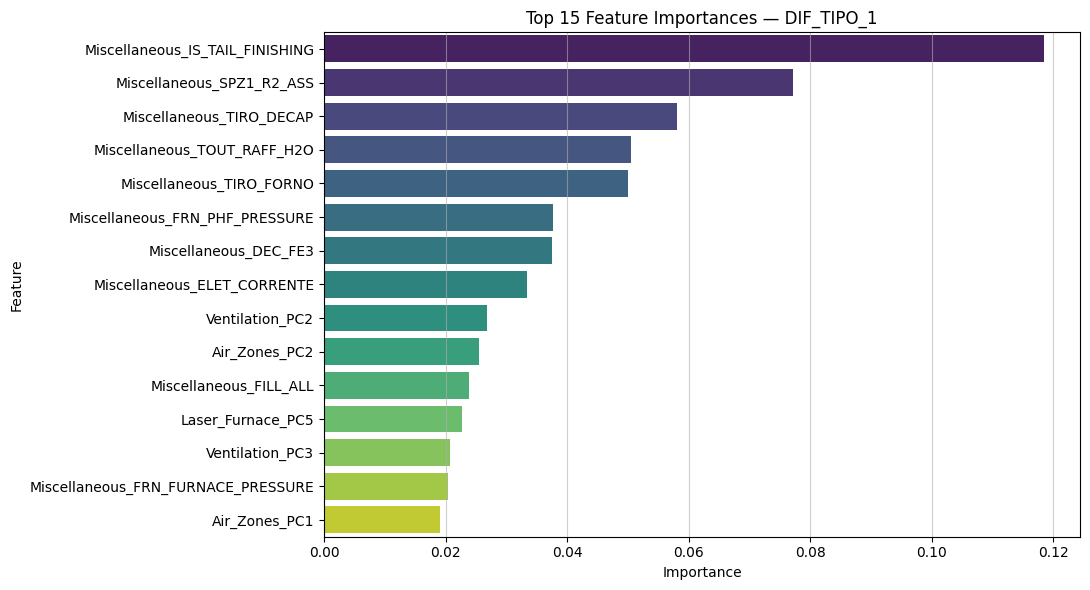

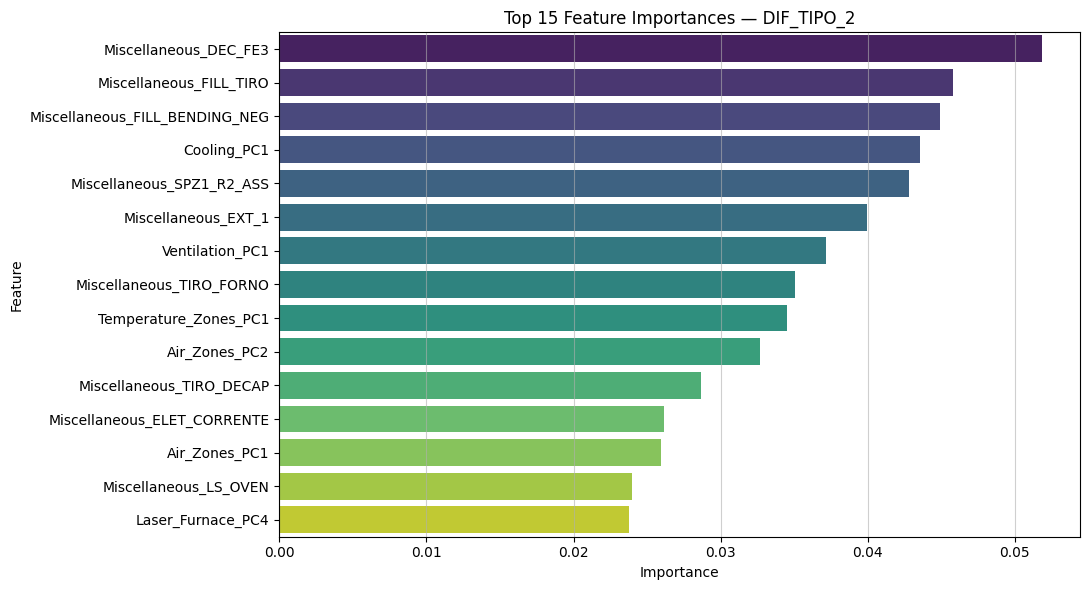

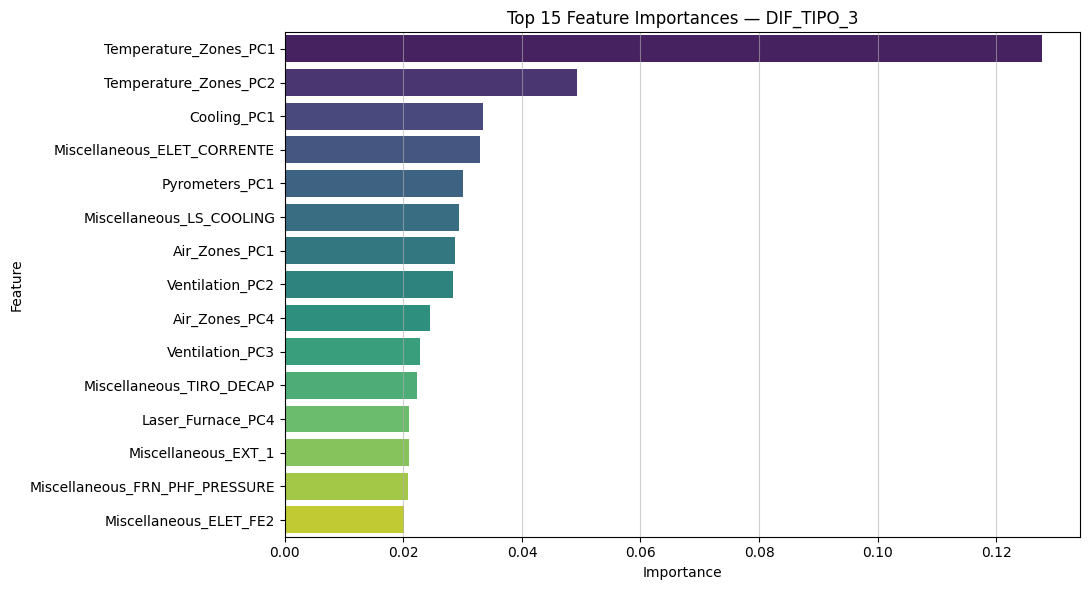

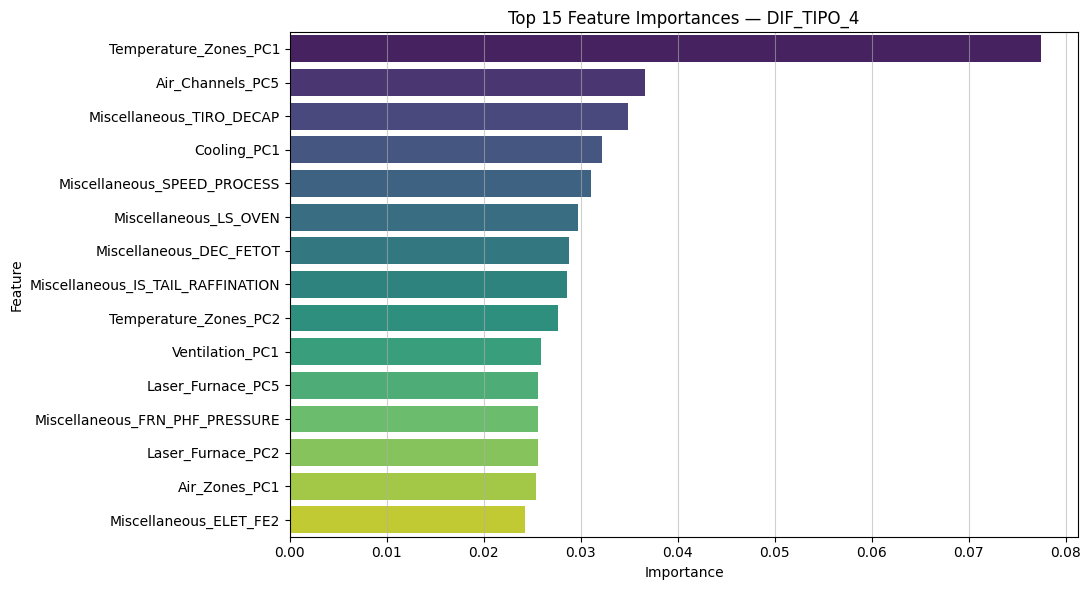

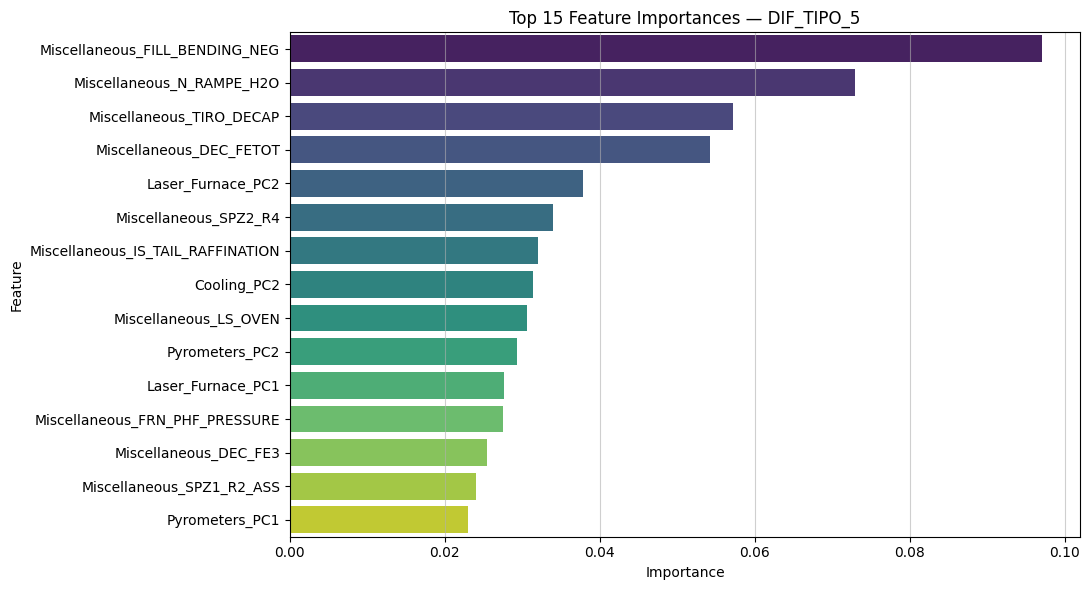

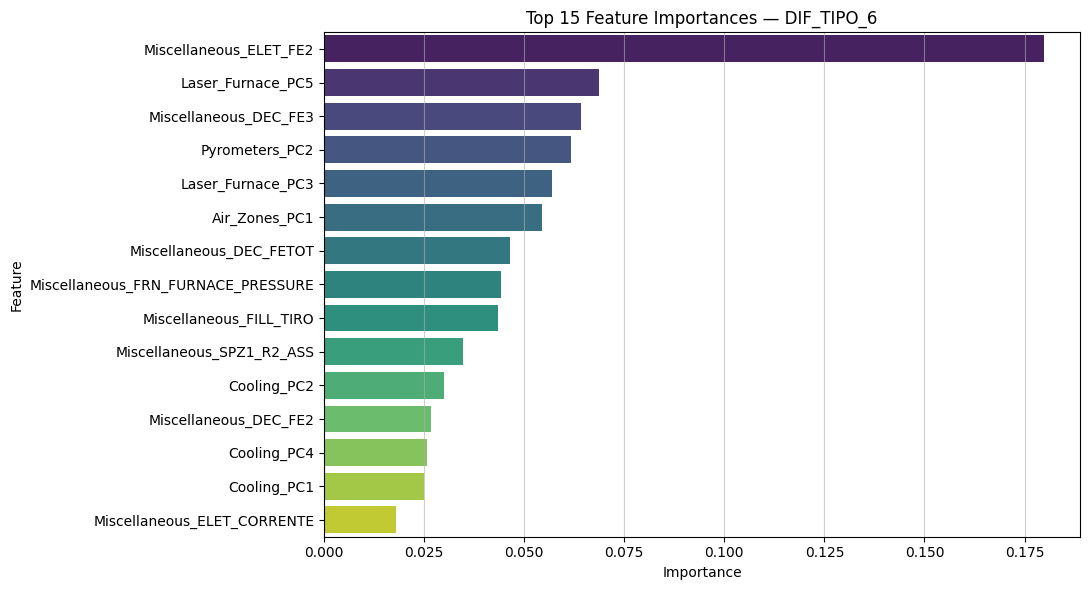

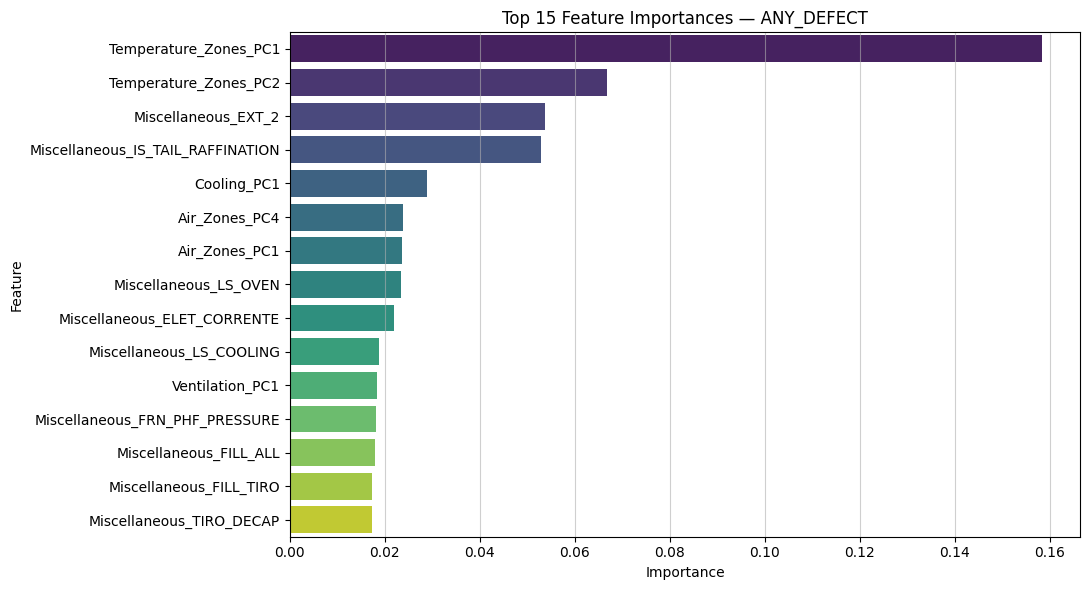

In [ ]:
for target in TARGETS:
    model, X_te, _, _, _, _, _ = last_fold_artifacts[target]
    fi = (
        pd.DataFrame({'Feature': X_base.columns, 'Importance': model.feature_importances_})
          .sort_values('Importance', ascending=False)
          .head(15)
    )
    fig, ax = plt.subplots(figsize=(11, 6))
    sns.barplot(x='Importance', y='Feature', data=fi, palette='viridis', ax=ax)
    ax.set(title=f'Top 15 Feature Importances — {target}',
           xlabel='Importance', ylabel='Feature')
    ax.grid(axis='x', alpha=0.6)
    plt.tight_layout()
    plt.show()


## 20 — SHAP Analysis  *(last fold, per target)*

SHAP (SHapley Additive exPlanations) attributes each prediction to individual
features in a game-theoretically fair way.

* **Bar plot** — mean absolute SHAP value (overall importance, no direction)
* **Beeswarm plot** — sign and magnitude of each feature's effect per sample



── SHAP: DIF_TIPO_1 ──


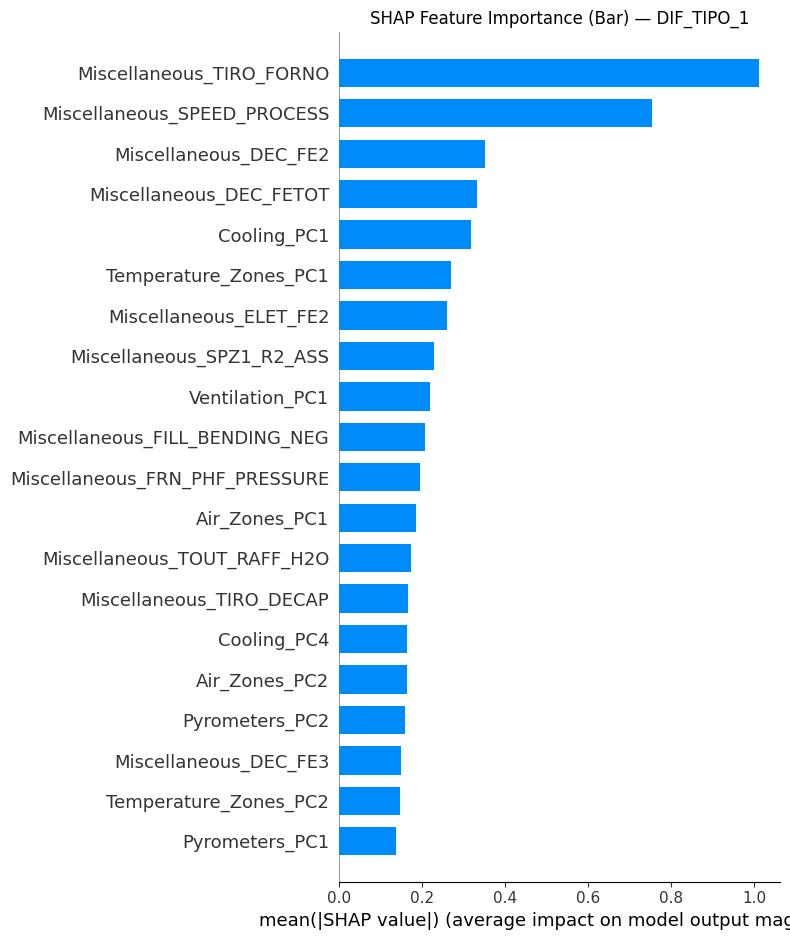

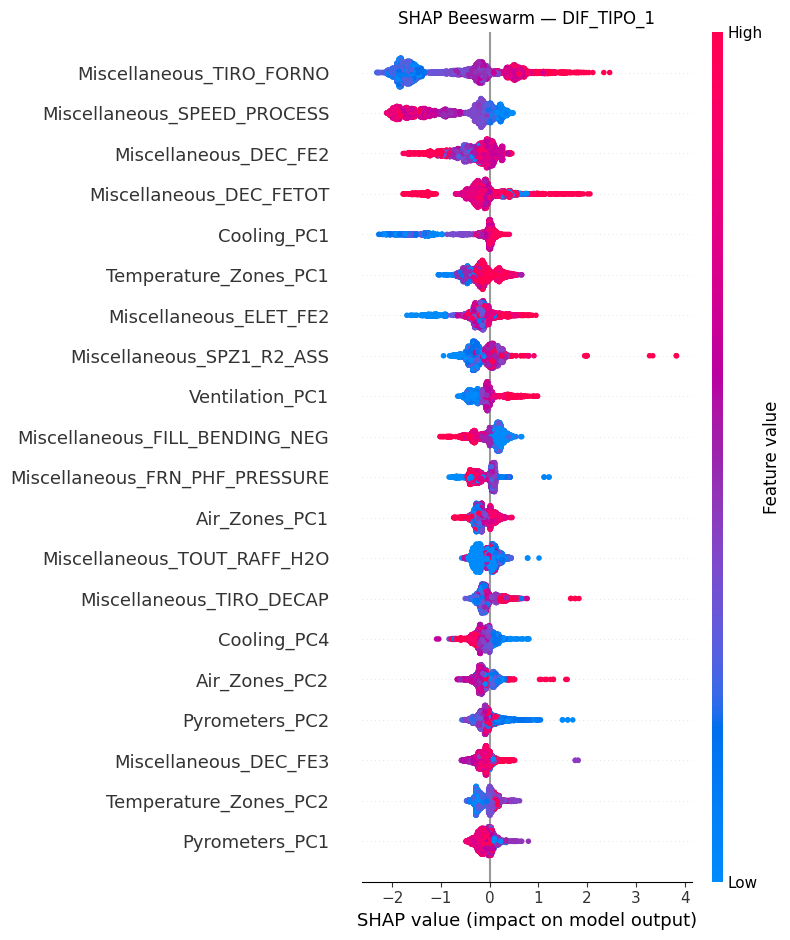


── SHAP: DIF_TIPO_2 ──


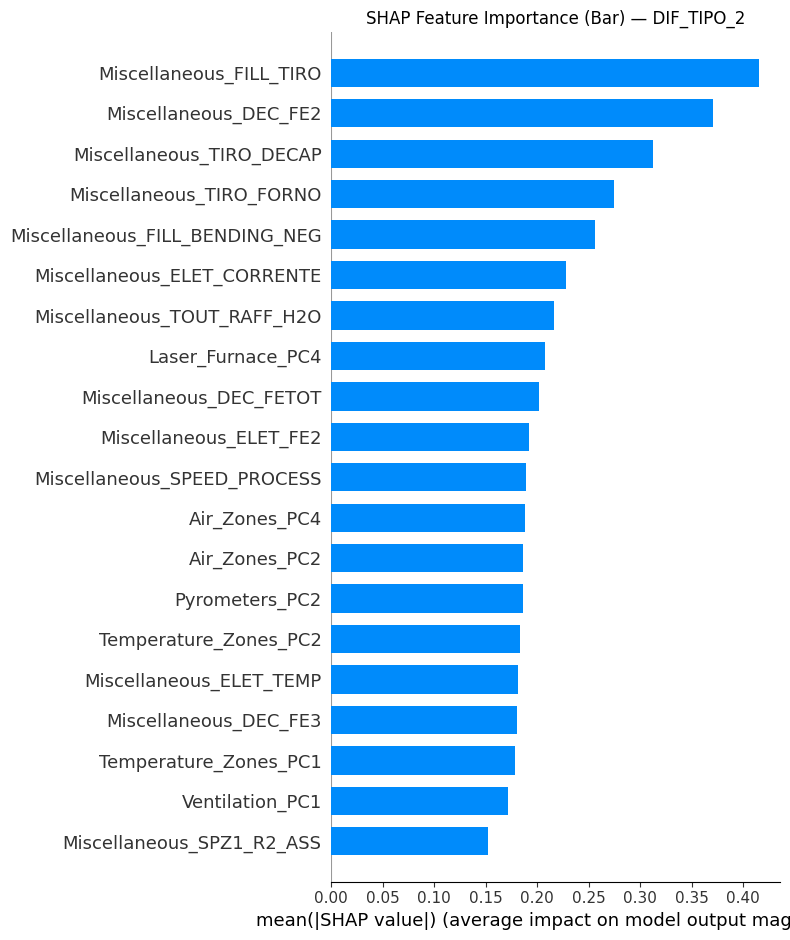

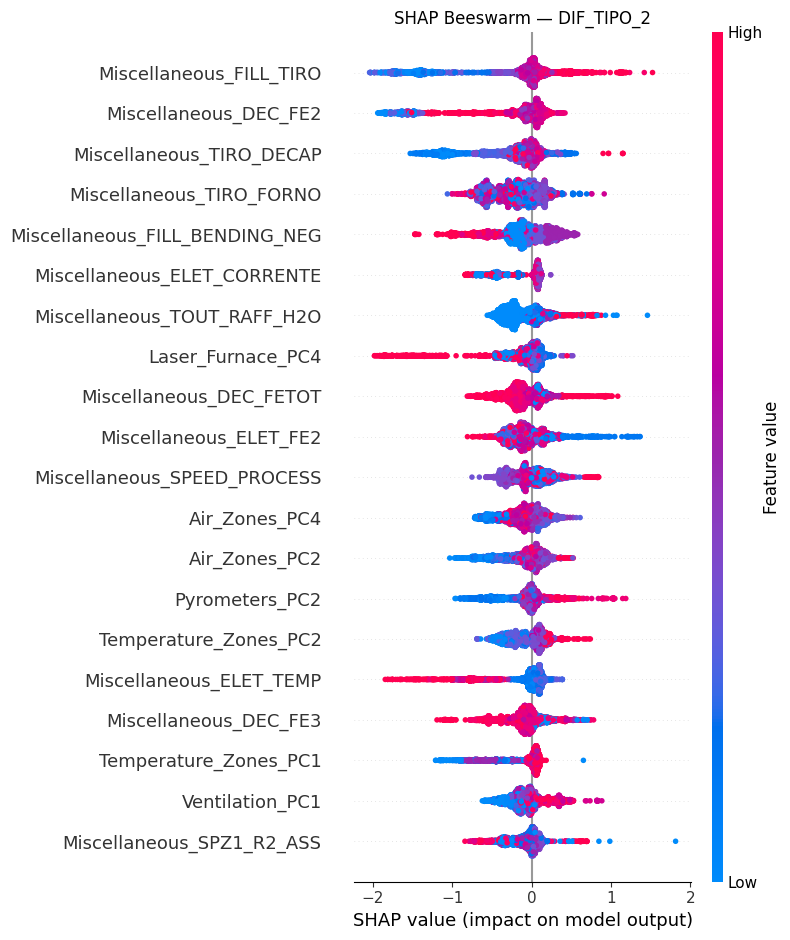


── SHAP: DIF_TIPO_3 ──


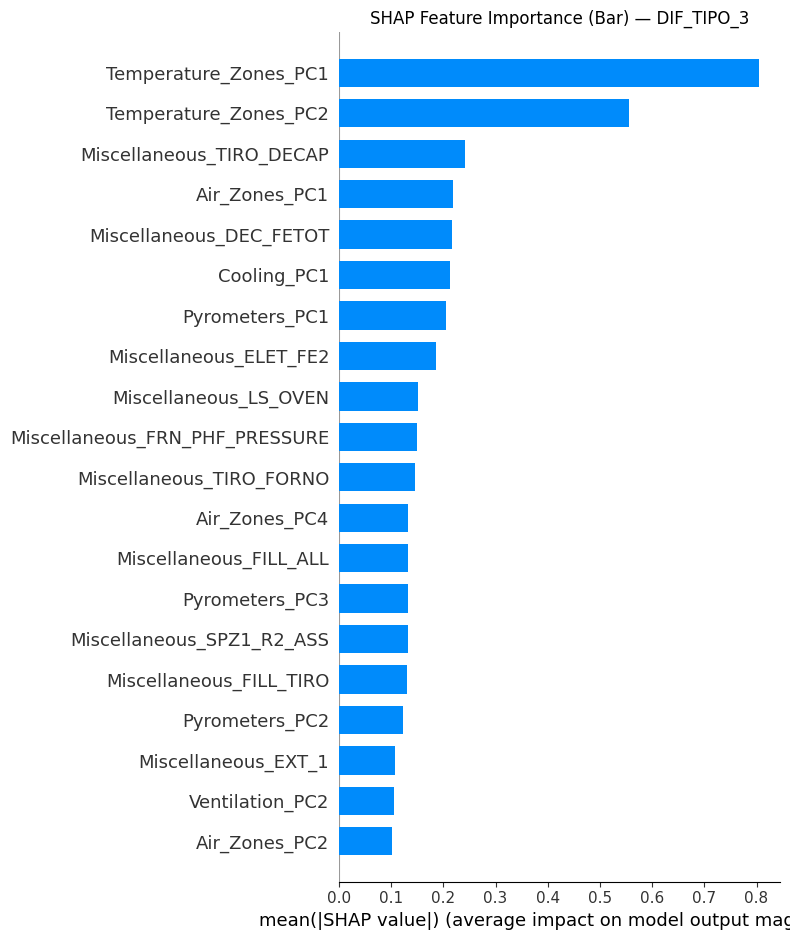

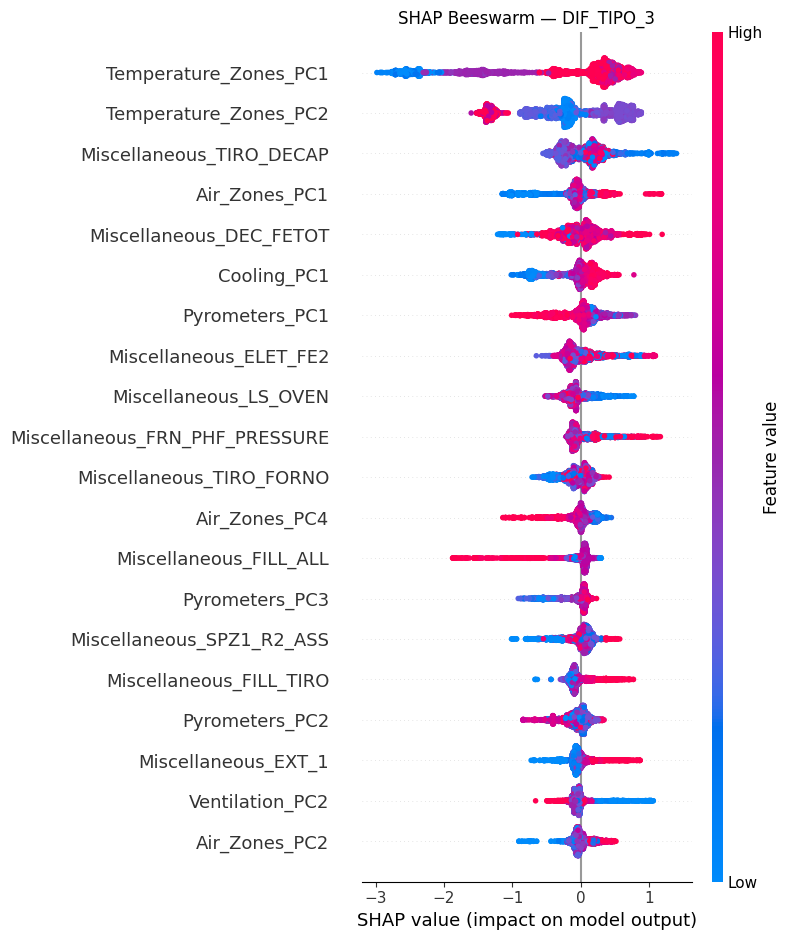


── SHAP: DIF_TIPO_4 ──


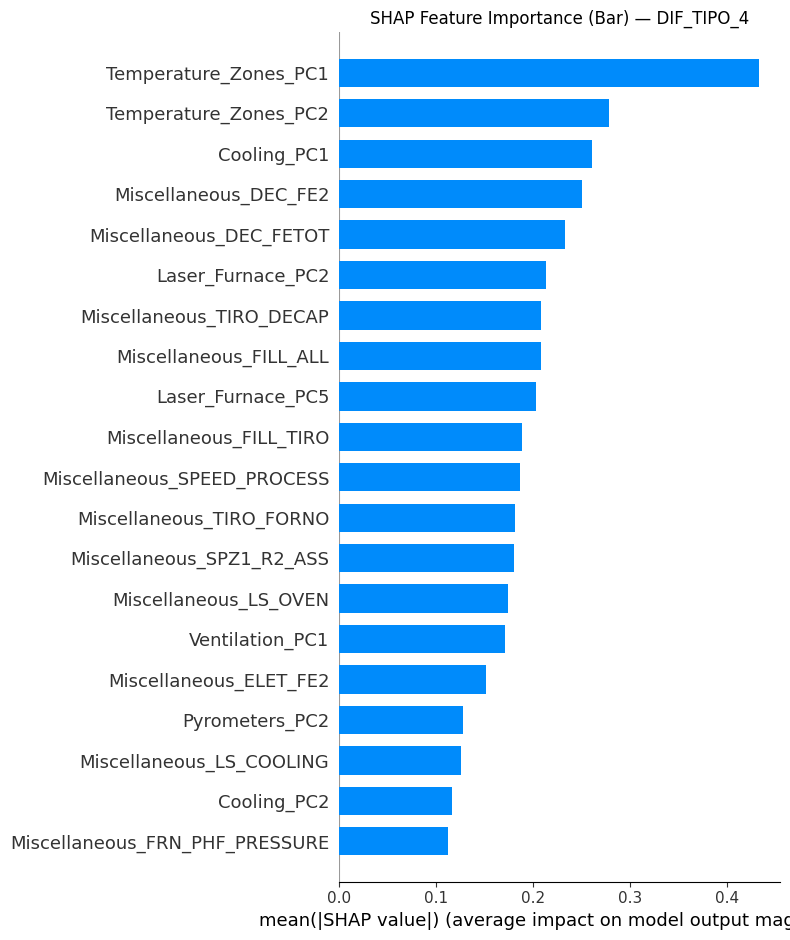

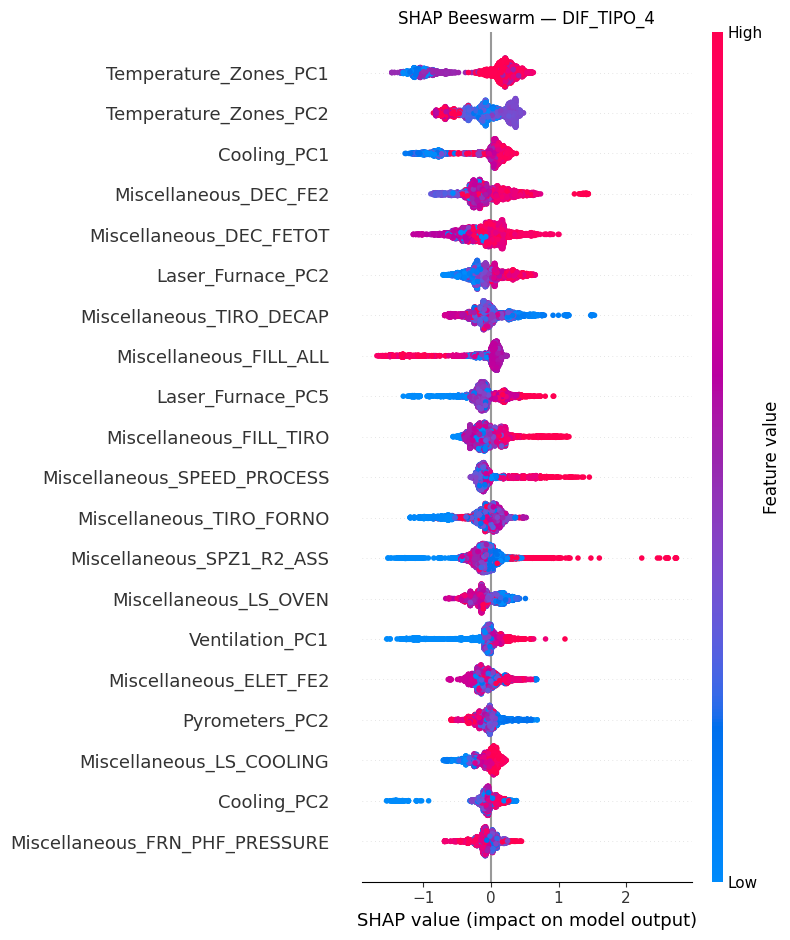


── SHAP: DIF_TIPO_5 ──


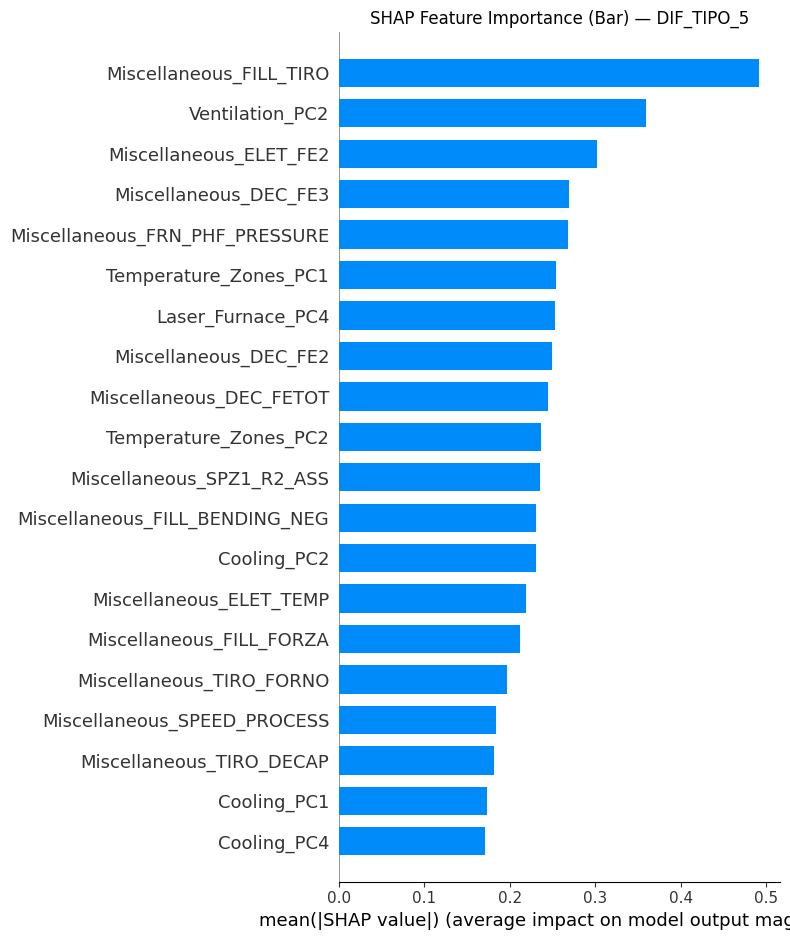

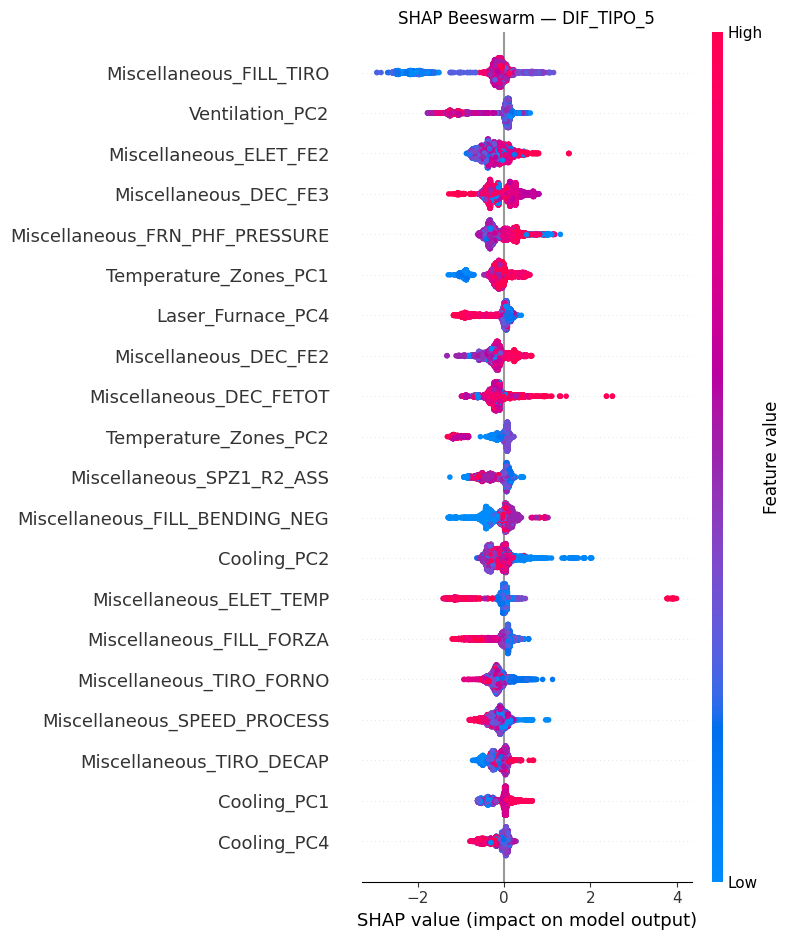


── SHAP: DIF_TIPO_6 ──


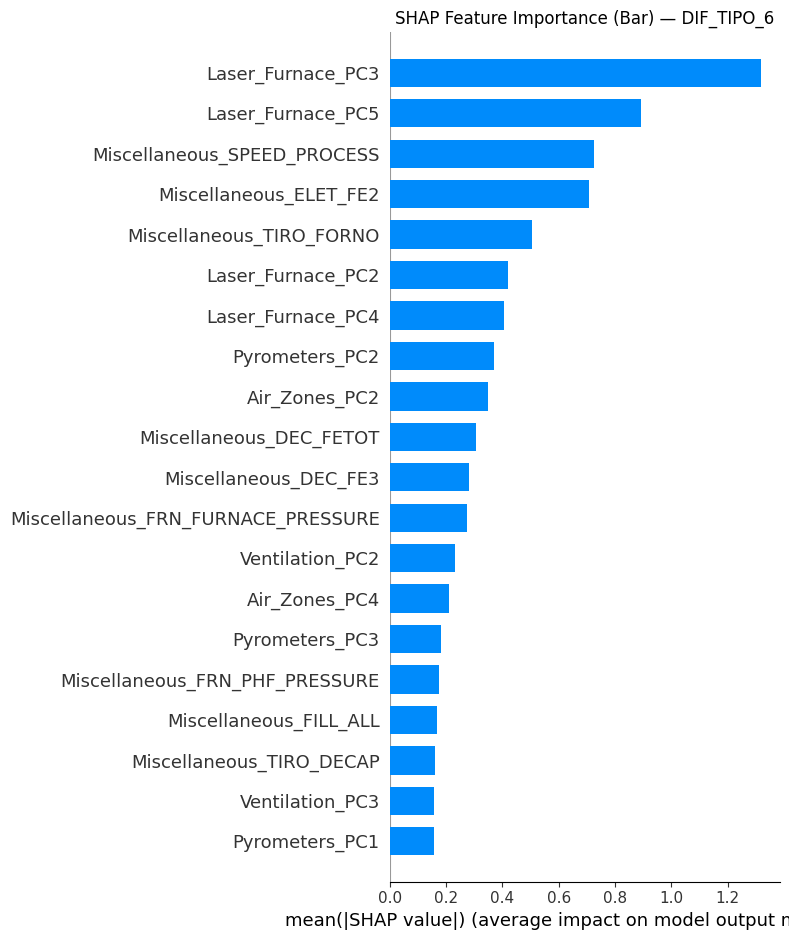

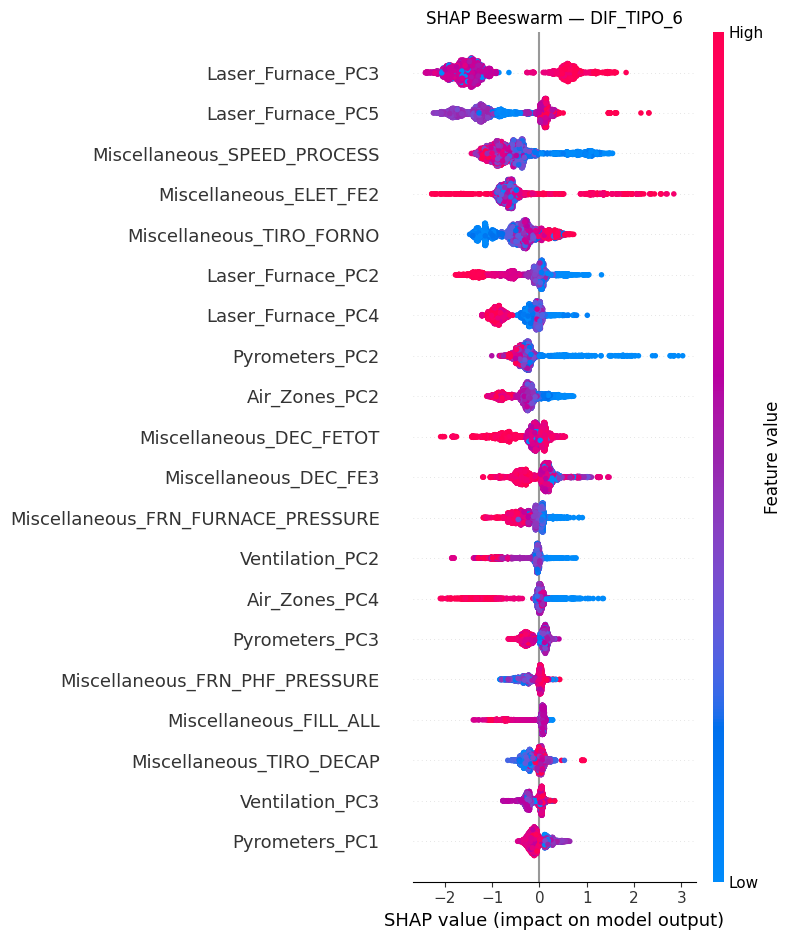


── SHAP: ANY_DEFECT ──


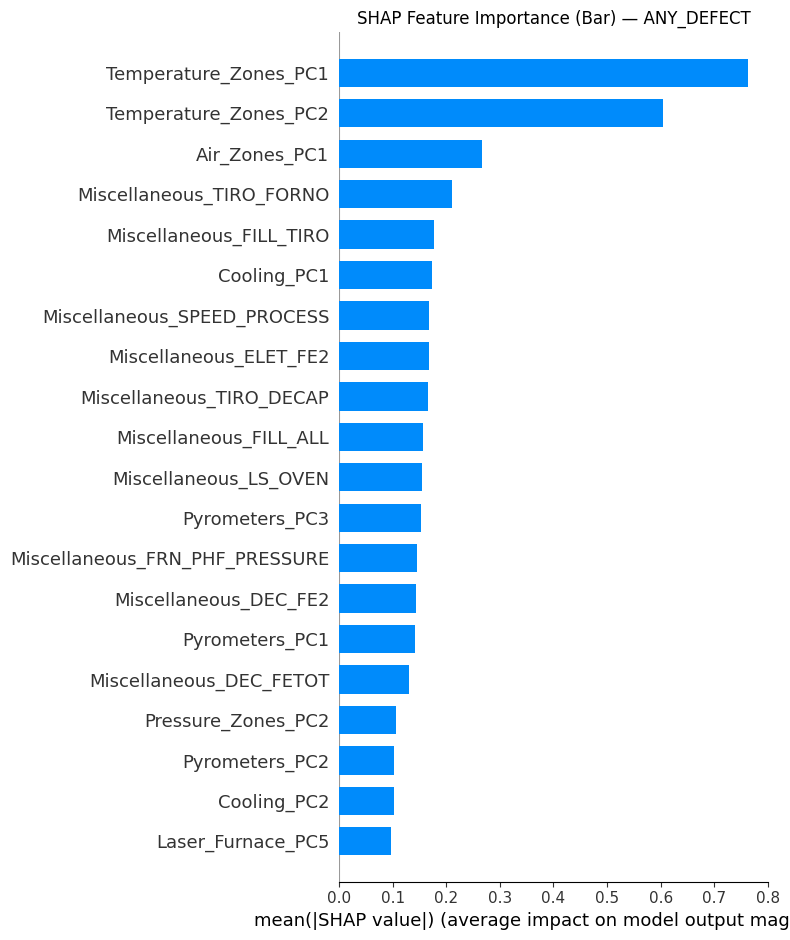

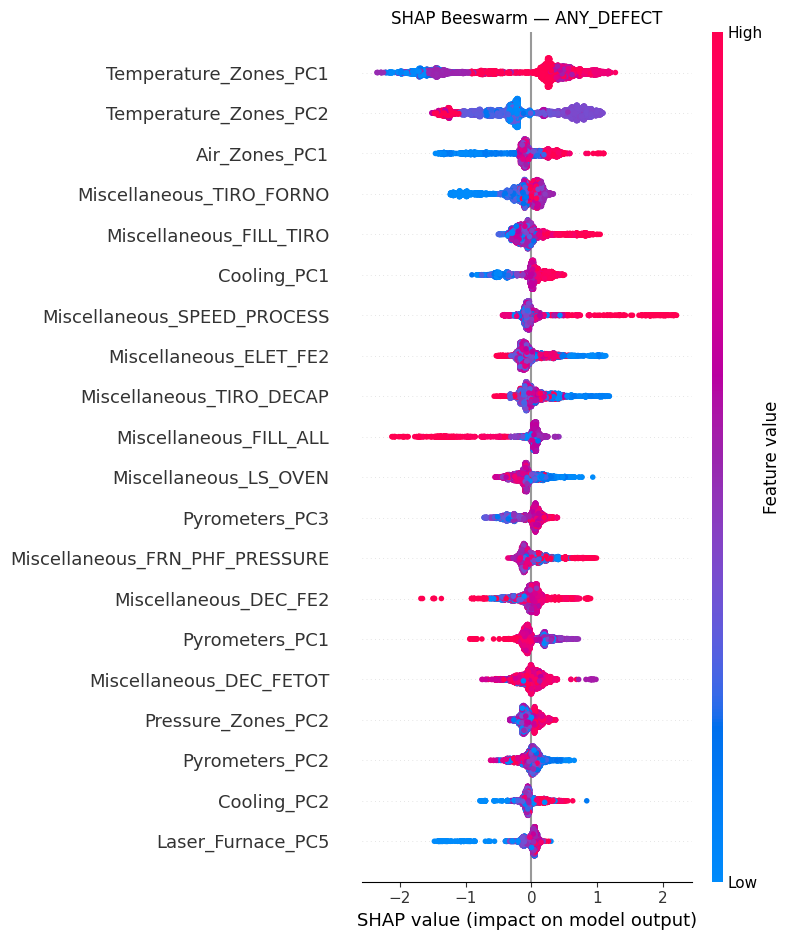

In [ ]:
import shap

SHAP_SAMPLE = 5000  # cap for speed; set to None to use the full test fold

for target in TARGETS:
    model, X_te, X_te_sc, _, _, _, _ = last_fold_artifacts[target]
    explainer = shap.TreeExplainer(model)

    if SHAP_SAMPLE and X_te_sc.shape[0] > SHAP_SAMPLE:
        rng  = np.random.default_rng(42)
        idx_ = rng.choice(X_te_sc.shape[0], SHAP_SAMPLE, replace=False)
        Xsc  = X_te_sc[idx_]
        Xdf  = X_te.iloc[idx_]
    else:
        Xsc, Xdf = X_te_sc, X_te

    shap_vals = explainer.shap_values(Xsc)

    print(f'\n── SHAP: {target} ──')
    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_vals, Xdf, plot_type='bar', show=False)
    plt.title(f'SHAP Feature Importance (Bar) — {target}')
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_vals, Xdf, show=False)
    plt.title(f'SHAP Beeswarm — {target}')
    plt.tight_layout(); plt.show()


### Interpretation of SHAP Plots

**Bar plot:** Average absolute SHAP value per feature — pure magnitude, no direction.

**Beeswarm plot:**
- Features sorted by total impact (top = most important).
- Each dot is one sample; horizontal position = contribution to the prediction
  (right → pushes toward *defect*, left → pushes toward *no defect*).
- Colour encodes the original feature value (red = high, blue = low).

Use these plots to understand *which sensors* drive each defect type and in
which direction — actionable input for process engineers.



── SHAP: DIF_TIPO_1 ──


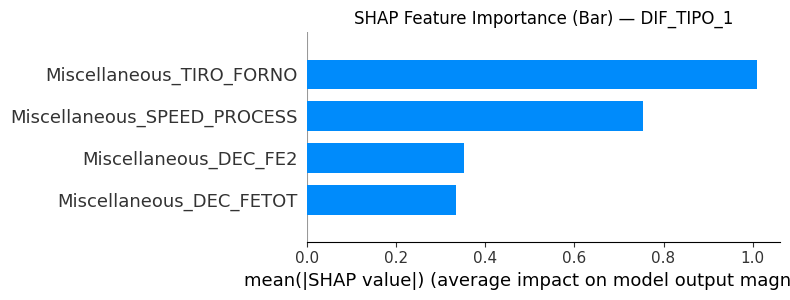


Top 4 features by Mean Absolute SHAP Value for DIF_TIPO_1:


,Feature,Mean_Abs_SHAP
34,Miscellaneous_TIRO_FORNO,1.0110
30,Miscellaneous_SPEED_PROCESS,0.7536
43,Miscellaneous_DEC_FE2,0.3511
45,Miscellaneous_DEC_FETOT,0.3330


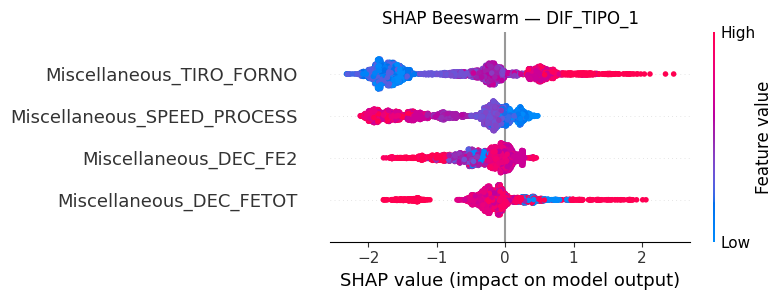


── SHAP: DIF_TIPO_2 ──


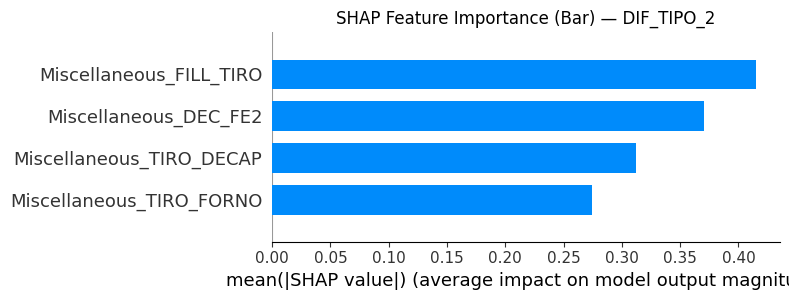


Top 4 features by Mean Absolute SHAP Value for DIF_TIPO_2:


,Feature,Mean_Abs_SHAP
52,Miscellaneous_FILL_TIRO,0.4149
43,Miscellaneous_DEC_FE2,0.3707
49,Miscellaneous_TIRO_DECAP,0.3125
34,Miscellaneous_TIRO_FORNO,0.2745


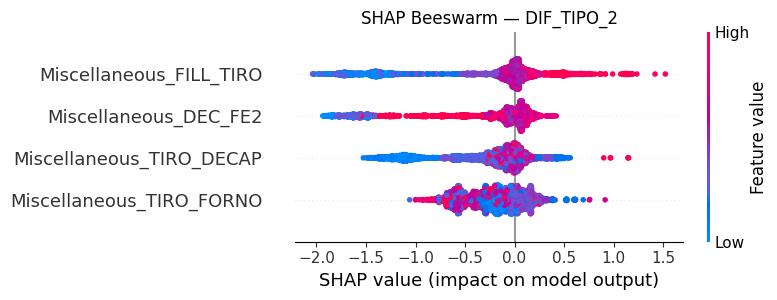


── SHAP: DIF_TIPO_3 ──


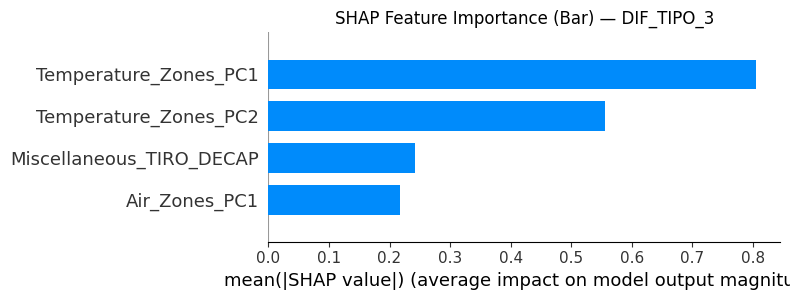


Top 4 features by Mean Absolute SHAP Value for DIF_TIPO_3:


,Feature,Mean_Abs_SHAP
0,Temperature_Zones_PC1,0.8047
1,Temperature_Zones_PC2,0.5552
49,Miscellaneous_TIRO_DECAP,0.2413
16,Air_Zones_PC1,0.2175


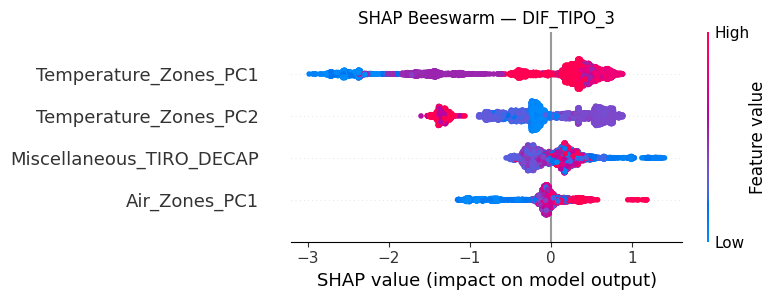


── SHAP: DIF_TIPO_4 ──


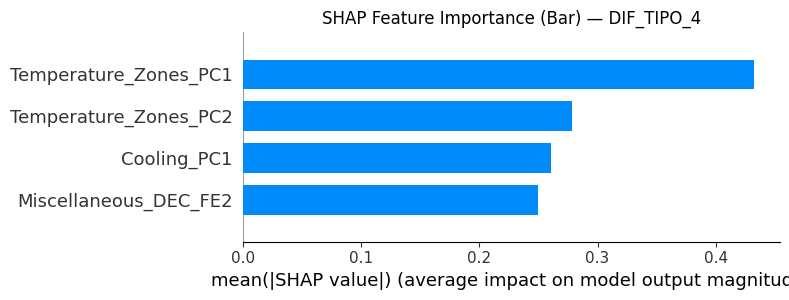


Top 4 features by Mean Absolute SHAP Value for DIF_TIPO_4:


,Feature,Mean_Abs_SHAP
0,Temperature_Zones_PC1,0.4326
1,Temperature_Zones_PC2,0.2784
26,Cooling_PC1,0.2606
43,Miscellaneous_DEC_FE2,0.2499


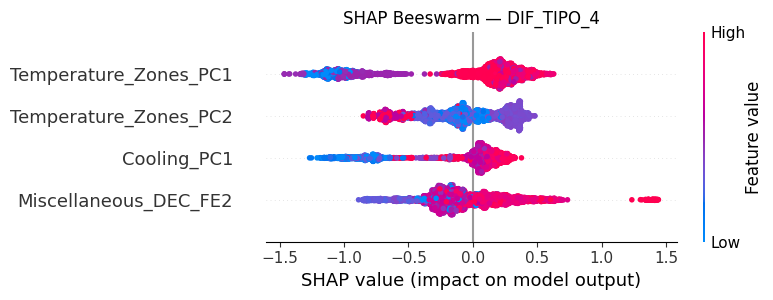


── SHAP: DIF_TIPO_5 ──


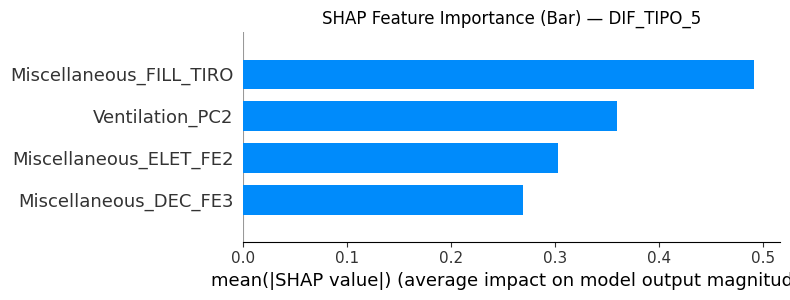


Top 4 features by Mean Absolute SHAP Value for DIF_TIPO_5:


,Feature,Mean_Abs_SHAP
52,Miscellaneous_FILL_TIRO,0.4917
24,Ventilation_PC2,0.3592
41,Miscellaneous_ELET_FE2,0.3024
44,Miscellaneous_DEC_FE3,0.2689


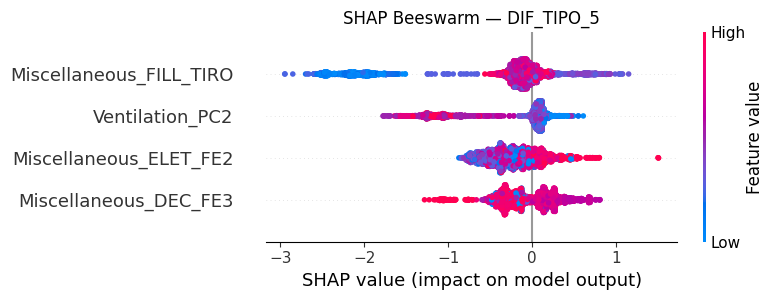


── SHAP: DIF_TIPO_6 ──


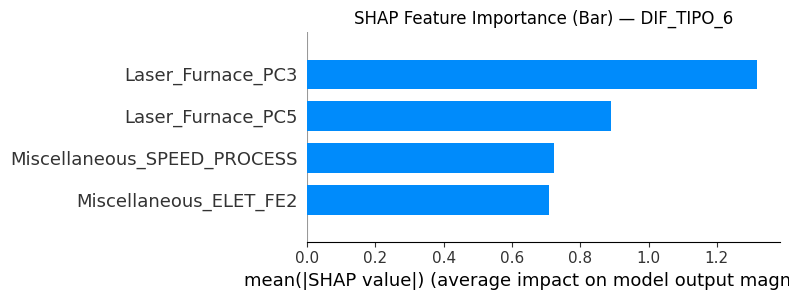


Top 4 features by Mean Absolute SHAP Value for DIF_TIPO_6:


,Feature,Mean_Abs_SHAP
7,Laser_Furnace_PC3,1.3193
9,Laser_Furnace_PC5,0.8904
30,Miscellaneous_SPEED_PROCESS,0.7241
41,Miscellaneous_ELET_FE2,0.7079


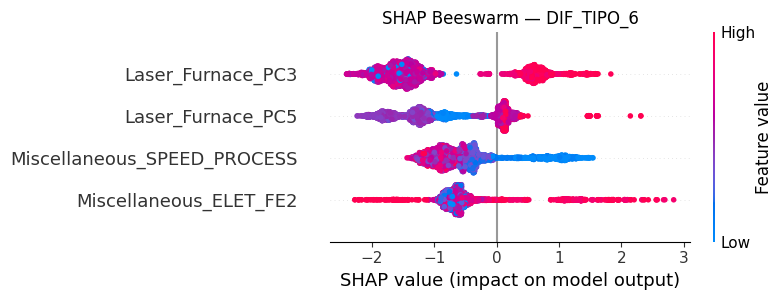


── SHAP: ANY_DEFECT ──


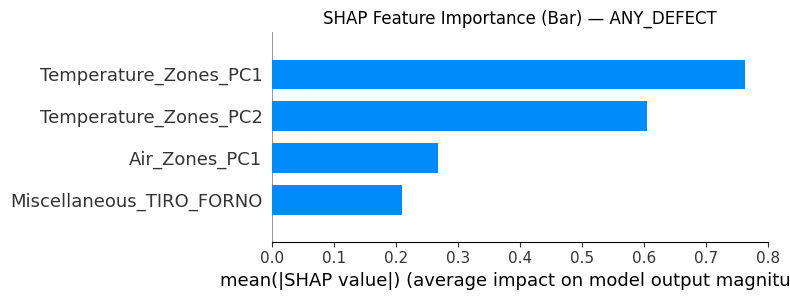


Top 4 features by Mean Absolute SHAP Value for ANY_DEFECT:


,Feature,Mean_Abs_SHAP
0,Temperature_Zones_PC1,0.7625
1,Temperature_Zones_PC2,0.6048
16,Air_Zones_PC1,0.2674
34,Miscellaneous_TIRO_FORNO,0.2100


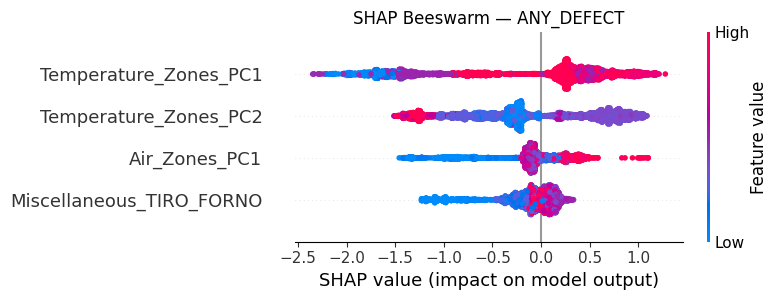

In [ ]:
import shap

SHAP_SAMPLE = 5000  # cap for speed; set to None to use the full test fold

for target in TARGETS:
    model, X_te, X_te_sc, _, _, _, _ = last_fold_artifacts[target]
    explainer = shap.TreeExplainer(model)

    if SHAP_SAMPLE and X_te_sc.shape[0] > SHAP_SAMPLE:
        rng  = np.random.default_rng(42)
        idx_ = rng.choice(X_te_sc.shape[0], SHAP_SAMPLE, replace=False)
        Xsc  = X_te_sc[idx_]
        Xdf  = X_te.iloc[idx_]
    else:
        Xsc, Xdf = X_te_sc, X_te

    shap_vals = explainer.shap_values(Xsc)

    print(f'\n── SHAP: {target} ──')
    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_vals, Xdf, plot_type='bar', max_display=4, show=False)
    plt.title(f'SHAP Feature Importance (Bar) — {target}')
    plt.tight_layout(); plt.show()

    # Calculate mean absolute SHAP values for textual display
    mean_abs_shap_values = np.abs(shap_vals).mean(axis=0)
    feature_importance_df = pd.DataFrame({
        'Feature': Xdf.columns,
        'Mean_Abs_SHAP': mean_abs_shap_values
    })
    # Sort by importance and get the top 'max_display' features (which is 4 here)
    top_features = feature_importance_df.sort_values(
        by='Mean_Abs_SHAP', ascending=False
    ).head(4)

    print(f'\nTop {len(top_features)} features by Mean Absolute SHAP Value for {target}:')
    display(top_features.style.format(precision=4))

    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_vals, Xdf, max_display=4, show=False)
    plt.title(f'SHAP Beeswarm — {target}')
    plt.tight_layout(); plt.show()